## Imports and Setup 

In [19]:
# ============================================================
# Cell 1 — Imports and Setup
# ============================================================

import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings

# Import our database helpers
from database.local_connection import get_local_engine, test_connection, read_sql

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"]   = (12, 6)
plt.rcParams["figure.dpi"]       = 100
plt.rcParams["font.size"]        = 11
plt.rcParams["axes.titlesize"]   = 14
plt.rcParams["axes.titleweight"] = "bold"


import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np
import warnings
from database.local_connection import read_sql

warnings.filterwarnings("ignore")

# ── Global Style ──────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"         : 150,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "#f8f9fa",
    "axes.edgecolor"     : "#dee2e6",
    "axes.linewidth"     : 0.8,
    "axes.grid"          : True,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "grid.color"         : "#e9ecef",
    "grid.linewidth"     : 0.6,
    "font.family"        : "DejaVu Sans",
    "font.size"          : 10,
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "bold",
    "axes.titlepad"      : 12,
    "axes.labelsize"     : 10,
    "axes.labelcolor"    : "#495057",
    "xtick.color"        : "#6c757d",
    "ytick.color"        : "#6c757d",
    "legend.framealpha"  : 0.9,
    "legend.edgecolor"   : "#dee2e6",
    "legend.fontsize"    : 9,
})

ACCENT   = "#2563eb"
POSITIVE = "#16a34a"
NEGATIVE = "#dc2626"
NEUTRAL  = "#6b7280"
PALETTE  = ["#2563eb","#16a34a","#dc2626","#d97706","#7c3aed",
            "#0891b2","#be185d","#065f46","#92400e","#1e3a5f"]

# ── Load Data ─────────────────────────────────────────────
query = """
    SELECT city, country, temperature_c, feels_like_c,
           temp_min_c, temp_max_c, humidity_pct, pressure_hpa,
           wind_speed_mps, cloudiness_pct, weather_condition,
           weather_description, visibility_m, extracted_at, created_at
    FROM weather_records
    ORDER BY created_at DESC
"""
df     = read_sql(query)
latest = df.drop_duplicates("city", keep="first").copy()
latest = latest.sort_values("temperature_c", ascending=False).reset_index(drop=True)

print(f" Ready — {len(latest)} cities loaded.")

print(" All libraries imported successfully.")

 Ready — 50 cities loaded.
 All libraries imported successfully.


## Test Database Connection

In [2]:
# ============================================================
# Cell 2 — Test Database Connection
# ============================================================

test_connection()

 Database connection successful!


True

## Load Data from PostgreSQL

In [3]:
# ============================================================
# Cell 3 — Load Data from PostgreSQL
# ============================================================

query = """
    SELECT
        city,
        country,
        temperature_c,
        feels_like_c,
        temp_min_c,
        temp_max_c,
        humidity_pct,
        pressure_hpa,
        wind_speed_mps,
        cloudiness_pct,
        weather_condition,
        weather_description,
        visibility_m,
        extracted_at,
        created_at
    FROM weather_records
    ORDER BY created_at DESC
"""

# Use our read_sql helper — handles all compatibility automatically
df = read_sql(query)

print(f" Data loaded successfully.")
print(f"   Total records : {len(df)}")
print(f"   Total columns : {len(df.columns)}")
print(f"   Cities        : {df['city'].tolist()}")
print(f"\n--- Data Preview ---")
df.head(10)

 Data loaded successfully.
   Total records : 100
   Total columns : 15
   Cities        : ['Johannesburg', 'Casablanca', 'Nairobi', 'Lagos', 'Cairo', 'Cape Town', 'Brisbane', 'Auckland', 'Melbourne', 'Sydney', 'Santiago', 'Bogota', 'Lima', 'Buenos Aires', 'Mexico City', 'São Paulo', 'Chicago', 'Los Angeles', 'Toronto', 'New York', 'Doha', 'Riyadh', 'Dhaka', 'Karachi', 'Hong Kong', 'Jakarta', 'Kuala Lumpur', 'Beijing', 'Seoul', 'Bangkok', 'Mumbai', 'Colombo', 'Dubai', 'Singapore', 'Tokyo', 'Budapest', 'Prague', 'Athens', 'Lisbon', 'Brussels', 'Zurich', 'Oslo', 'Stockholm', 'Vienna', 'Amsterdam', 'Madrid', 'Rome', 'Berlin', 'Paris', 'London', 'Toronto', 'Berlin', 'Singapore', 'Colombo', 'Dubai', 'Sydney', 'Paris', 'Tokyo', 'New York', 'London', 'Toronto', 'Berlin', 'Singapore', 'Colombo', 'Dubai', 'Sydney', 'Paris', 'Tokyo', 'New York', 'London', 'Toronto', 'Berlin', 'Singapore', 'Colombo', 'Dubai', 'Sydney', 'Paris', 'Tokyo', 'New York', 'London', 'Toronto', 'Berlin', 'Singapore', 'Col

,city,country,temperature_c,feels_like_c,temp_min_c,temp_max_c,humidity_pct,pressure_hpa,wind_speed_mps,cloudiness_pct,weather_condition,weather_description,visibility_m,extracted_at,created_at
0,Johannesburg,ZA,19.25,19.55,18.94,19.93,89,1017,0.51,100,Rain,light rain,10000,2026-03-22 10:28:24,2026-03-22 10:28:34.037463+00:00
1,Casablanca,MA,18.07,17.68,17.96,20.12,67,1009,2.06,40,Rain,light rain,5000,2026-03-22 10:28:23,2026-03-22 10:28:34.036212+00:00
2,Nairobi,KE,22.62,22.50,22.62,22.62,60,1011,3.09,75,Clouds,broken clouds,10000,2026-03-22 10:28:23,2026-03-22 10:28:34.034312+00:00
3,Lagos,NG,31.96,36.68,31.96,31.96,59,1010,3.12,73,Rain,light rain,10000,2026-03-22 10:28:23,2026-03-22 10:28:34.030964+00:00
4,Cairo,EG,19.42,18.31,19.12,19.42,34,1010,4.12,40,Clouds,scattered clouds,10000,2026-03-22 10:28:22,2026-03-22 10:28:34.028617+00:00
5,Cape Town,ZA,22.42,22.44,21.62,23.27,66,1013,7.20,0,Clear,clear sky,10000,2026-03-22 10:28:22,2026-03-22 10:28:34.027202+00:00
6,Brisbane,AU,22.98,23.47,22.17,23.80,82,1018,2.57,56,Clouds,broken clouds,10000,2026-03-22 10:28:21,2026-03-22 10:28:34.025684+00:00
7,Auckland,NZ,17.90,17.34,15.97,18.21,61,1026,1.54,75,Clouds,broken clouds,10000,2026-03-22 10:28:21,2026-03-22 10:28:34.023483+00:00
8,Melbourne,US,16.21,15.77,12.25,16.65,72,1018,3.09,0,Clear,clear sky,10000,2026-03-22 10:28:21,2026-03-22 10:28:34.022534+00:00
9,Sydney,AU,22.48,22.82,21.38,22.98,78,1021,4.63,20,Clouds,few clouds,10000,2026-03-22 10:28:20,2026-03-22 10:28:34.021332+00:00


## Data Summary and Info

In [4]:
# ============================================================
# Cell 4 — Data Summary and Info
# ============================================================

print("=== DATASET INFO ===")
print(f"Shape         : {df.shape}")
print(f"Date range    : {df['extracted_at'].min()} → {df['extracted_at'].max()}")
print(f"\n=== DESCRIPTIVE STATISTICS ===")
df[["temperature_c","feels_like_c","humidity_pct",
    "wind_speed_mps","pressure_hpa","cloudiness_pct"]].describe().round(2)

=== DATASET INFO ===
Shape         : (100, 15)
Date range    : 2026-03-22 09:38:01 → 2026-03-22 10:28:24

=== DESCRIPTIVE STATISTICS ===


,temperature_c,feels_like_c,humidity_pct,wind_speed_mps,pressure_hpa,cloudiness_pct
count,100.00,100.00,100.00,100.00,100.00,100.00
mean,17.30,17.14,67.08,4.48,1013.37,38.30
std,9.47,11.99,15.01,1.95,5.44,37.76
min,1.14,-4.69,11.00,0.00,1002.00,0.00
25%,10.27,9.00,60.00,3.09,1009.75,0.00
50%,13.98,12.89,67.00,4.95,1013.00,20.00
75%,26.54,26.54,77.00,6.04,1017.00,75.00
max,35.02,42.02,99.00,8.39,1026.00,100.00


## Temperature Comparison

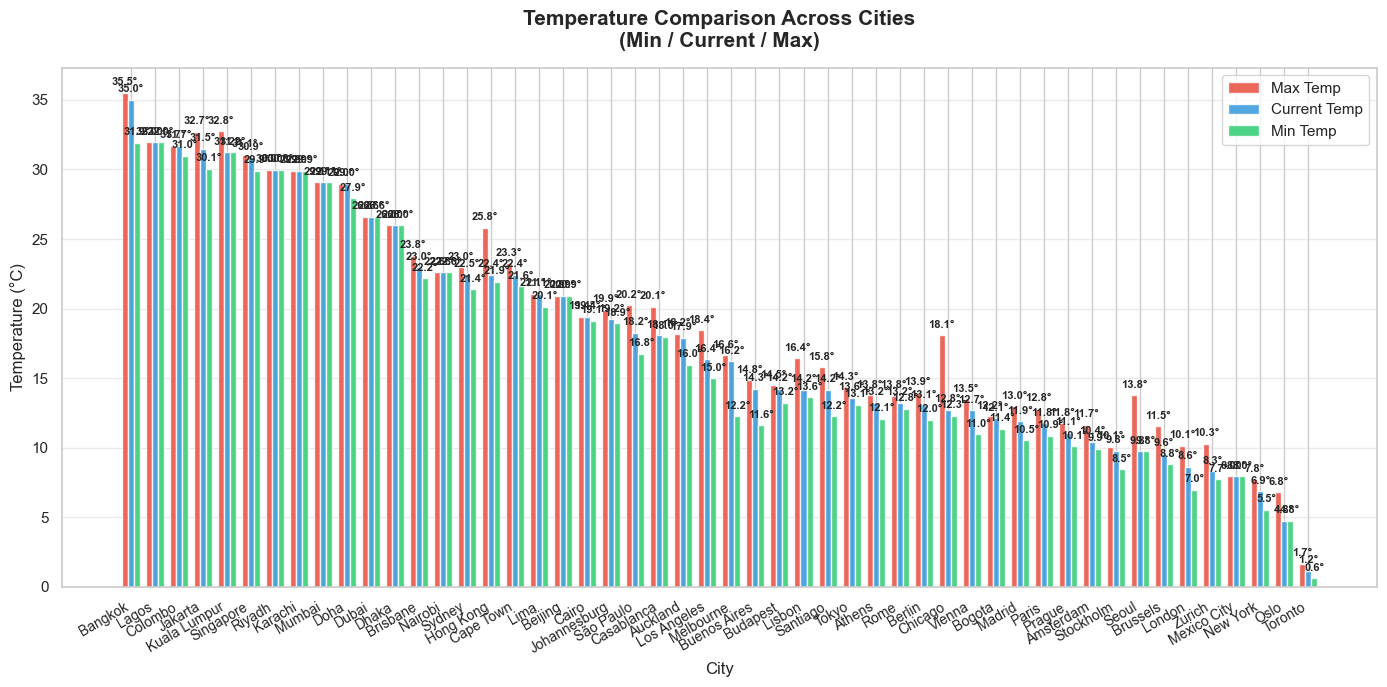

Visualization 1 saved.


In [6]:
# ============================================================
#  Temperature Comparison by City
# ============================================================

# Get latest record per city
latest = df.sort_values("created_at").drop_duplicates("city", keep="last")
latest = latest.sort_values("temperature_c", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

x      = range(len(latest))
width  = 0.25

bars1 = ax.bar([i - width for i in x], latest["temp_max_c"],
               width=width, label="Max Temp",
               color="#e74c3c", alpha=0.85, edgecolor="white")

bars2 = ax.bar([i for i in x], latest["temperature_c"],
               width=width, label="Current Temp",
               color="#3498db", alpha=0.85, edgecolor="white")

bars3 = ax.bar([i + width for i in x], latest["temp_min_c"],
               width=width, label="Min Temp",
               color="#2ecc71", alpha=0.85, edgecolor="white")

# Add value labels on bars
for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        ax.annotate(
            f"{height:.1f}°",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )

ax.set_xticks(list(x))
ax.set_xticklabels(latest["city"], rotation=30, ha="right", fontsize=10)
ax.set_xlabel("City",        fontsize=12)
ax.set_ylabel("Temperature (°C)", fontsize=12)
ax.set_title("Temperature Comparison Across Cities\n(Min / Current / Max)",
             fontsize=15, fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("../notebooks/viz1_temperature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualization 1 saved.")

## Humidity Levels

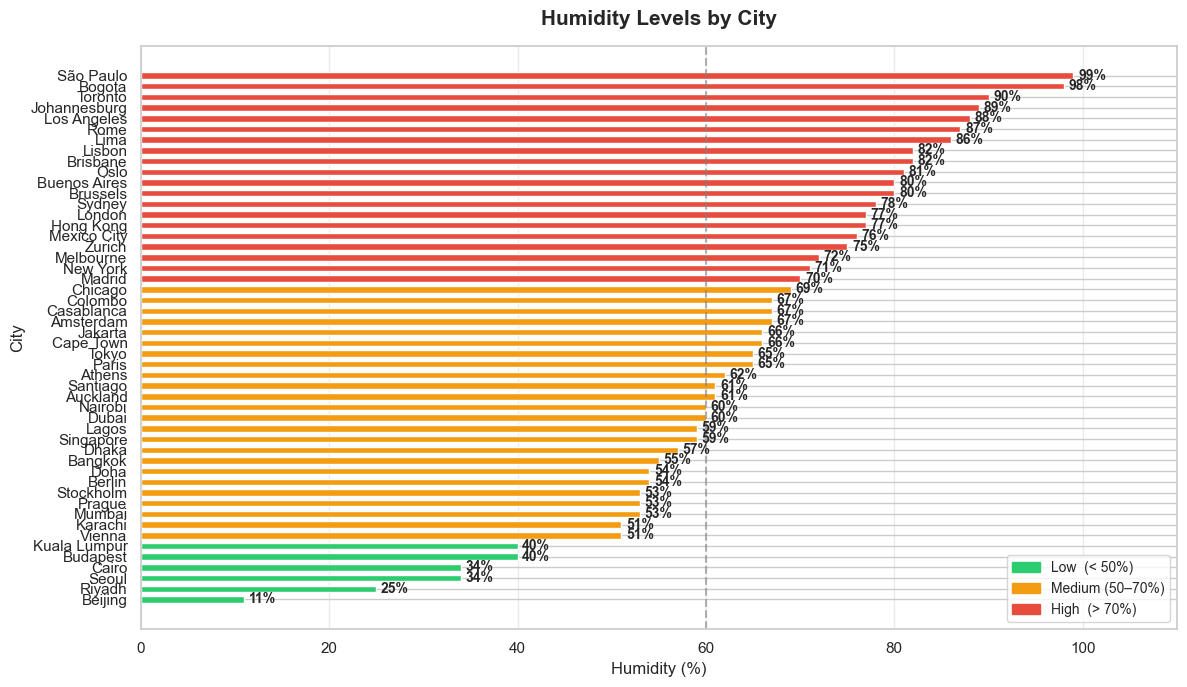

Visualization 2 saved.


In [7]:
# ============================================================
# Humidity Levels by City
# ============================================================

latest_sorted = latest.sort_values("humidity_pct", ascending=True)

colors = [
    "#2ecc71" if h < 50 else
    "#f39c12" if h < 70 else
    "#e74c3c"
    for h in latest_sorted["humidity_pct"]
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    latest_sorted["city"],
    latest_sorted["humidity_pct"],
    color=colors,
    edgecolor="white",
    height=0.6
)

# Add value labels
for bar, val in zip(bars, latest_sorted["humidity_pct"]):
    ax.text(
        val + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{val}%",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )

# Add reference line at 60%
ax.axvline(x=60, color="gray", linestyle="--", alpha=0.6, label="60% reference")

# Legend
low    = mpatches.Patch(color="#2ecc71", label="Low  (< 50%)")
medium = mpatches.Patch(color="#f39c12", label="Medium (50–70%)")
high   = mpatches.Patch(color="#e74c3c", label="High  (> 70%)")
ax.legend(handles=[low, medium, high], loc="lower right", fontsize=10)

ax.set_xlabel("Humidity (%)", fontsize=12)
ax.set_ylabel("City",         fontsize=12)
ax.set_title("Humidity Levels by City",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlim(0, 110)
ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig("../notebooks/viz2_humidity_levels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualization 2 saved.")

## Wind Speed Analysis

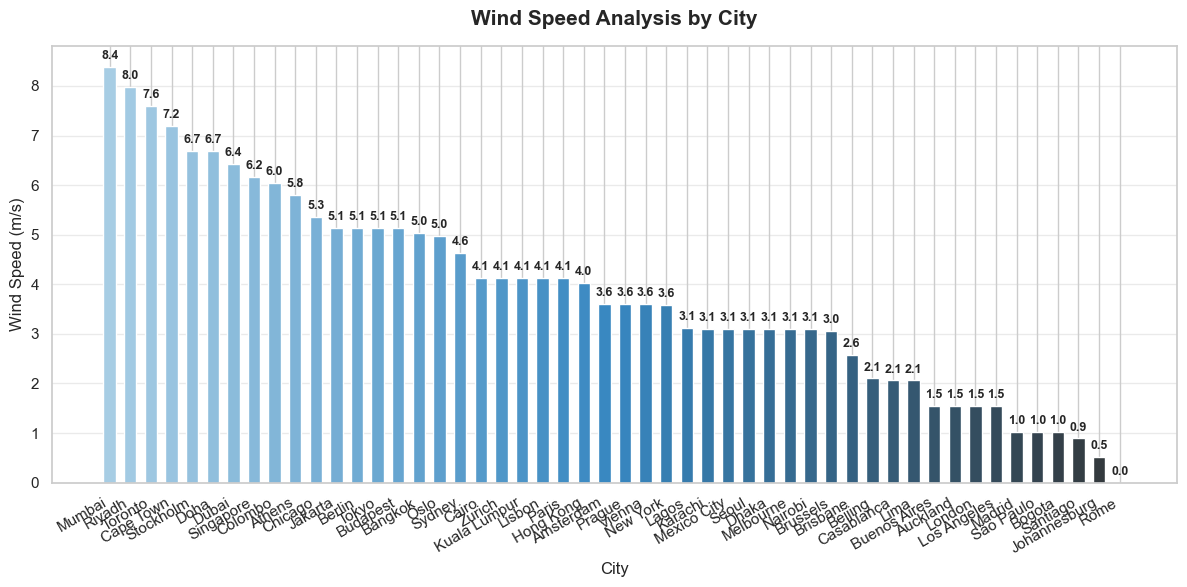

 Visualization 3 saved.


In [10]:
# ============================================================
#  Wind Speed Analysis
# ============================================================

latest_wind = latest.sort_values("wind_speed_mps", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors_wind = sns.color_palette("Blues_d", len(latest_wind))

bars = ax.bar(
    latest_wind["city"],
    latest_wind["wind_speed_mps"],
    color=colors_wind,
    edgecolor="white",
    width=0.6
)

for bar, val in zip(bars, latest_wind["wind_speed_mps"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.1f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

ax.set_xlabel("City",               fontsize=12)
ax.set_ylabel("Wind Speed (m/s)",   fontsize=12)
ax.set_title("Wind Speed Analysis by City",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xticklabels(latest_wind["city"], rotation=30, ha="right")
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("../notebooks/viz3_wind_speed.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Visualization 3 saved.")

## Weather Conditions Distribution

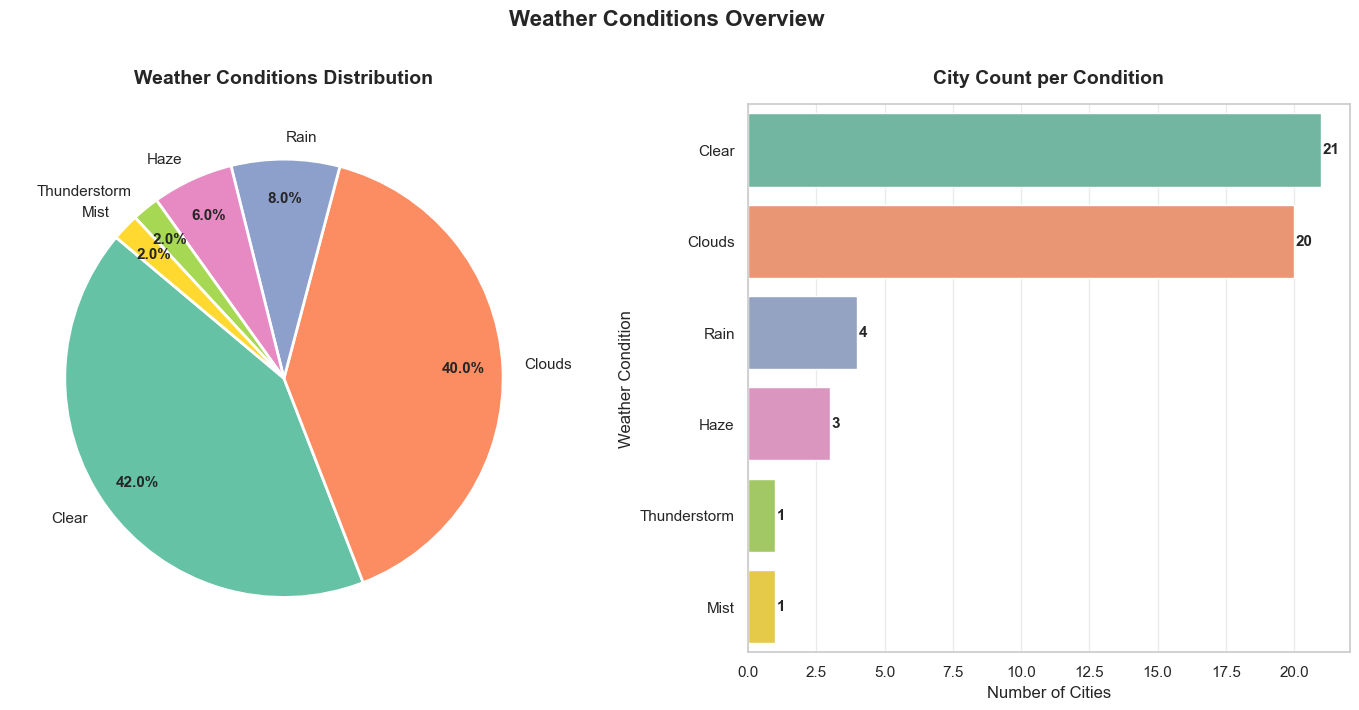

 Visualization 4 saved.


In [18]:
# ============================================================
#  Weather Conditions Distribution
# ============================================================

condition_counts = latest["weather_condition"].value_counts()

colors_pie = sns.color_palette("Set2", len(condition_counts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Pie chart
wedges, texts, autotexts = ax1.pie(
    condition_counts.values,
    labels=condition_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=140,
    pctdistance=0.82,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight("bold")

ax1.set_title("Weather Conditions Distribution",
              fontsize=14, fontweight="bold", pad=15)

# Bar chart alongside
sns.barplot(
    x=condition_counts.values,
    y=condition_counts.index,
    palette="Set2",
    ax=ax2
)
for i, val in enumerate(condition_counts.values):
    ax2.text(val + 0.05, i, str(val),
             va="center", fontsize=11, fontweight="bold")

ax2.set_xlabel("Number of Cities", fontsize=12)
ax2.set_ylabel("Weather Condition", fontsize=12)
ax2.set_title("City Count per Condition",
              fontsize=14, fontweight="bold", pad=15)
ax2.grid(axis="x", alpha=0.4)

plt.suptitle("Weather Conditions Overview",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../notebooks/viz4_weather_conditions.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Visualization 4 saved.")

## Temperature vs Humidity Scatter

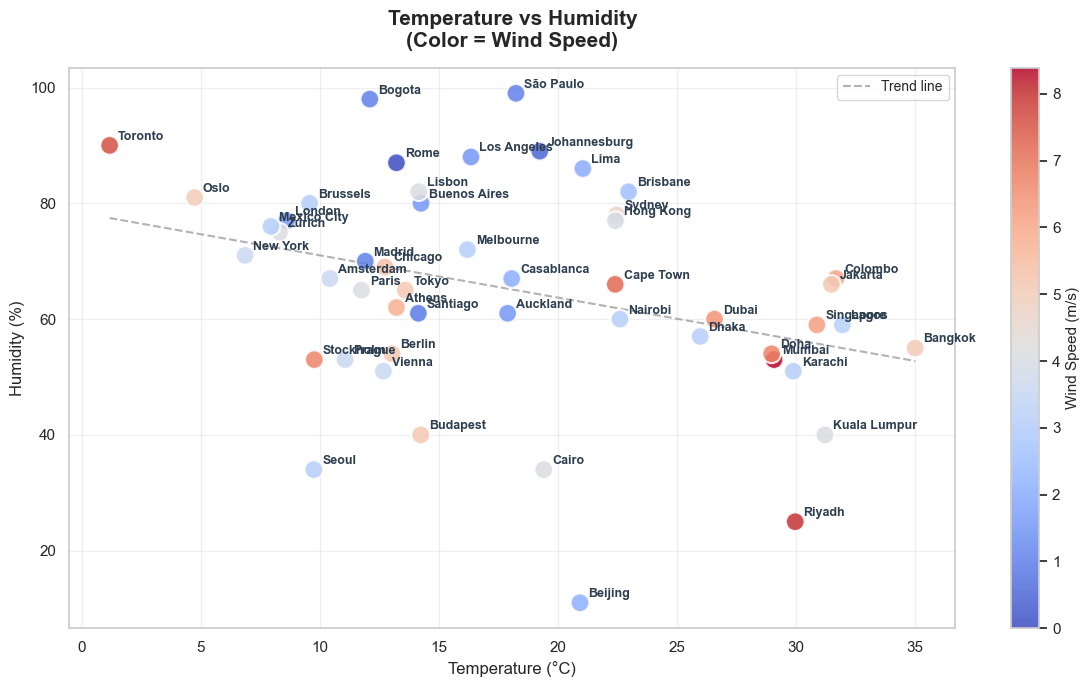

 Visualization 5 saved.


In [17]:
# ============================================================
# Temperature vs Humidity Scatter Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    latest["temperature_c"],
    latest["humidity_pct"],
    c=latest["wind_speed_mps"],
    cmap="coolwarm",
    s=180,
    alpha=0.85,
    edgecolors="white",
    linewidths=1.5,
    zorder=3
)

# Add city labels next to each point
for _, row in latest.iterrows():
    ax.annotate(
        row["city"],
        xy=(row["temperature_c"], row["humidity_pct"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="#2c3e50"
    )

# Colorbar for wind speed
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Wind Speed (m/s)", fontsize=11)

# Trend line
z   = pd.Series(latest["temperature_c"])
p   = pd.Series(latest["humidity_pct"])
fit = pd.Series(
    pd.np.polyfit(z, p, 1) if hasattr(pd, "np")
    else __import__("numpy").polyfit(z, p, 1)
)

import numpy as np
m, b    = np.polyfit(latest["temperature_c"], latest["humidity_pct"], 1)
x_line  = np.linspace(latest["temperature_c"].min(), latest["temperature_c"].max(), 100)
y_line  = m * x_line + b
ax.plot(x_line, y_line, color="gray", linestyle="--",
        alpha=0.6, linewidth=1.5, label="Trend line")

ax.set_xlabel("Temperature (°C)",  fontsize=12)
ax.set_ylabel("Humidity (%)",       fontsize=12)
ax.set_title("Temperature vs Humidity\n(Color = Wind Speed)",
             fontsize=15, fontweight="bold", pad=15)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../notebooks/viz5_temp_vs_humidity.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Visualization 5 saved.")

## Feels Like vs Actual Temperature

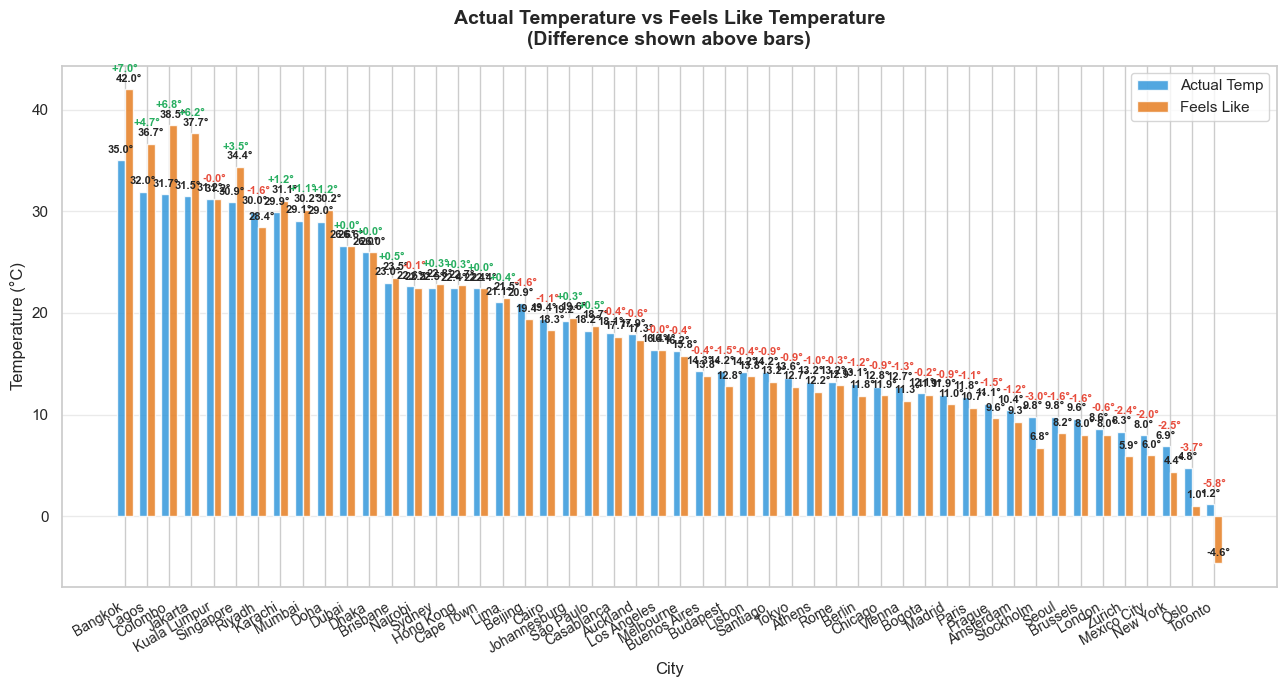

Visualization 6 saved.


In [16]:
# ============================================================
#  Feels Like vs Actual Temperature
# ============================================================

import numpy as np

latest_sorted6 = latest.sort_values("temperature_c", ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))

x      = np.arange(len(latest_sorted6))
width  = 0.35

bars_actual = ax.bar(
    x - width / 2,
    latest_sorted6["temperature_c"],
    width,
    label="Actual Temp",
    color="#3498db",
    alpha=0.85,
    edgecolor="white"
)

bars_feels = ax.bar(
    x + width / 2,
    latest_sorted6["feels_like_c"],
    width,
    label="Feels Like",
    color="#e67e22",
    alpha=0.85,
    edgecolor="white"
)

# Add value labels
for bar in [bars_actual, bars_feels]:
    for rect in bar:
        height = rect.get_height()
        ax.annotate(
            f"{height:.1f}°",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8, fontweight="bold"
        )

# Difference annotation
for i, (_, row) in enumerate(latest_sorted6.iterrows()):
    diff = row["feels_like_c"] - row["temperature_c"]
    color = "#e74c3c" if diff < 0 else "#27ae60"
    ax.annotate(
        f"{diff:+.1f}°",
        xy=(i, max(row["temperature_c"], row["feels_like_c"]) + 1.5),
        ha="center", va="bottom",
        fontsize=8, color=color, fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(latest_sorted6["city"], rotation=30, ha="right", fontsize=10)
ax.set_xlabel("City",               fontsize=12)
ax.set_ylabel("Temperature (°C)",   fontsize=12)
ax.set_title("Actual Temperature vs Feels Like Temperature\n(Difference shown above bars)",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("../notebooks/viz6_feels_like_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualization 6 saved.")

## Ranked Temperature Bar Chart with Range Bands

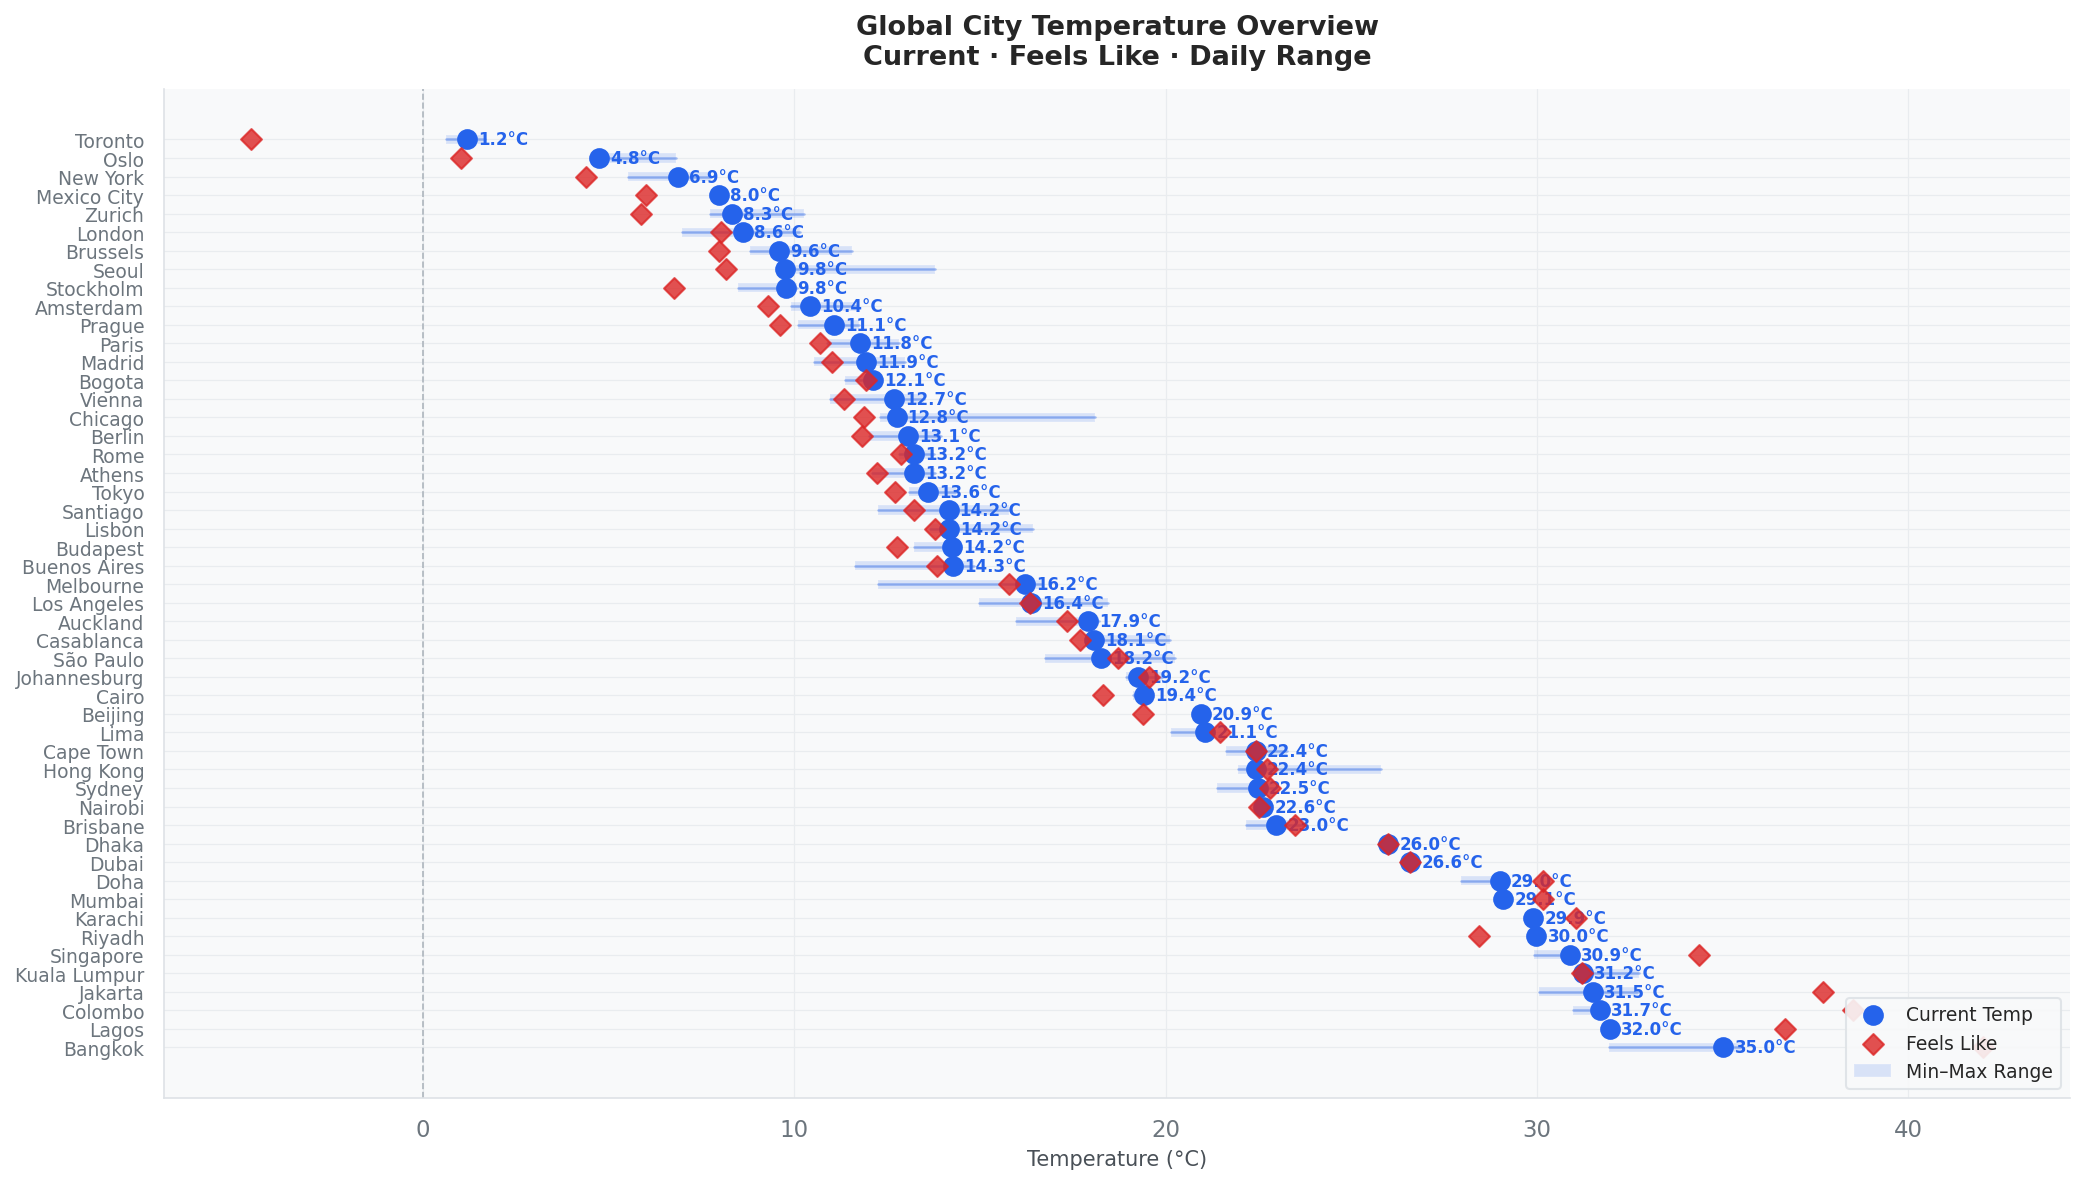

In [20]:
# ── VIZ 1: Ranked Temperature with Min/Max Range Bands ───

fig, ax = plt.subplots(figsize=(14, 8))

y     = np.arange(len(latest))
cities = latest["city"]

# Range band (min → max)
ax.barh(y, latest["temp_max_c"] - latest["temp_min_c"],
        left=latest["temp_min_c"],
        height=0.5, color=ACCENT, alpha=0.15, label="Min–Max Range")

# Current temperature marker
ax.scatter(latest["temperature_c"], y,
           color=ACCENT, s=80, zorder=5, label="Current Temp")

# Feels like marker
ax.scatter(latest["feels_like_c"], y,
           color=NEGATIVE, s=50, marker="D", zorder=5,
           label="Feels Like", alpha=0.8)

# Connecting line between min and max
for i, row in latest.iterrows():
    ax.plot([row["temp_min_c"], row["temp_max_c"]], [i, i],
            color=ACCENT, linewidth=1.2, alpha=0.4)

# Value labels
for i, row in latest.iterrows():
    ax.text(row["temperature_c"] + 0.3, i,
            f"{row['temperature_c']:.1f}°C",
            va="center", fontsize=8, color=ACCENT, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(cities, fontsize=9)
ax.set_xlabel("Temperature (°C)")
ax.set_title("Global City Temperature Overview\nCurrent · Feels Like · Daily Range")
ax.legend(loc="lower right")
ax.axvline(0, color="#adb5bd", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("../notebooks/viz1_temperature_ranked.png", dpi=150, bbox_inches="tight")
plt.show()

## Heat Map: City vs Weather Metrics

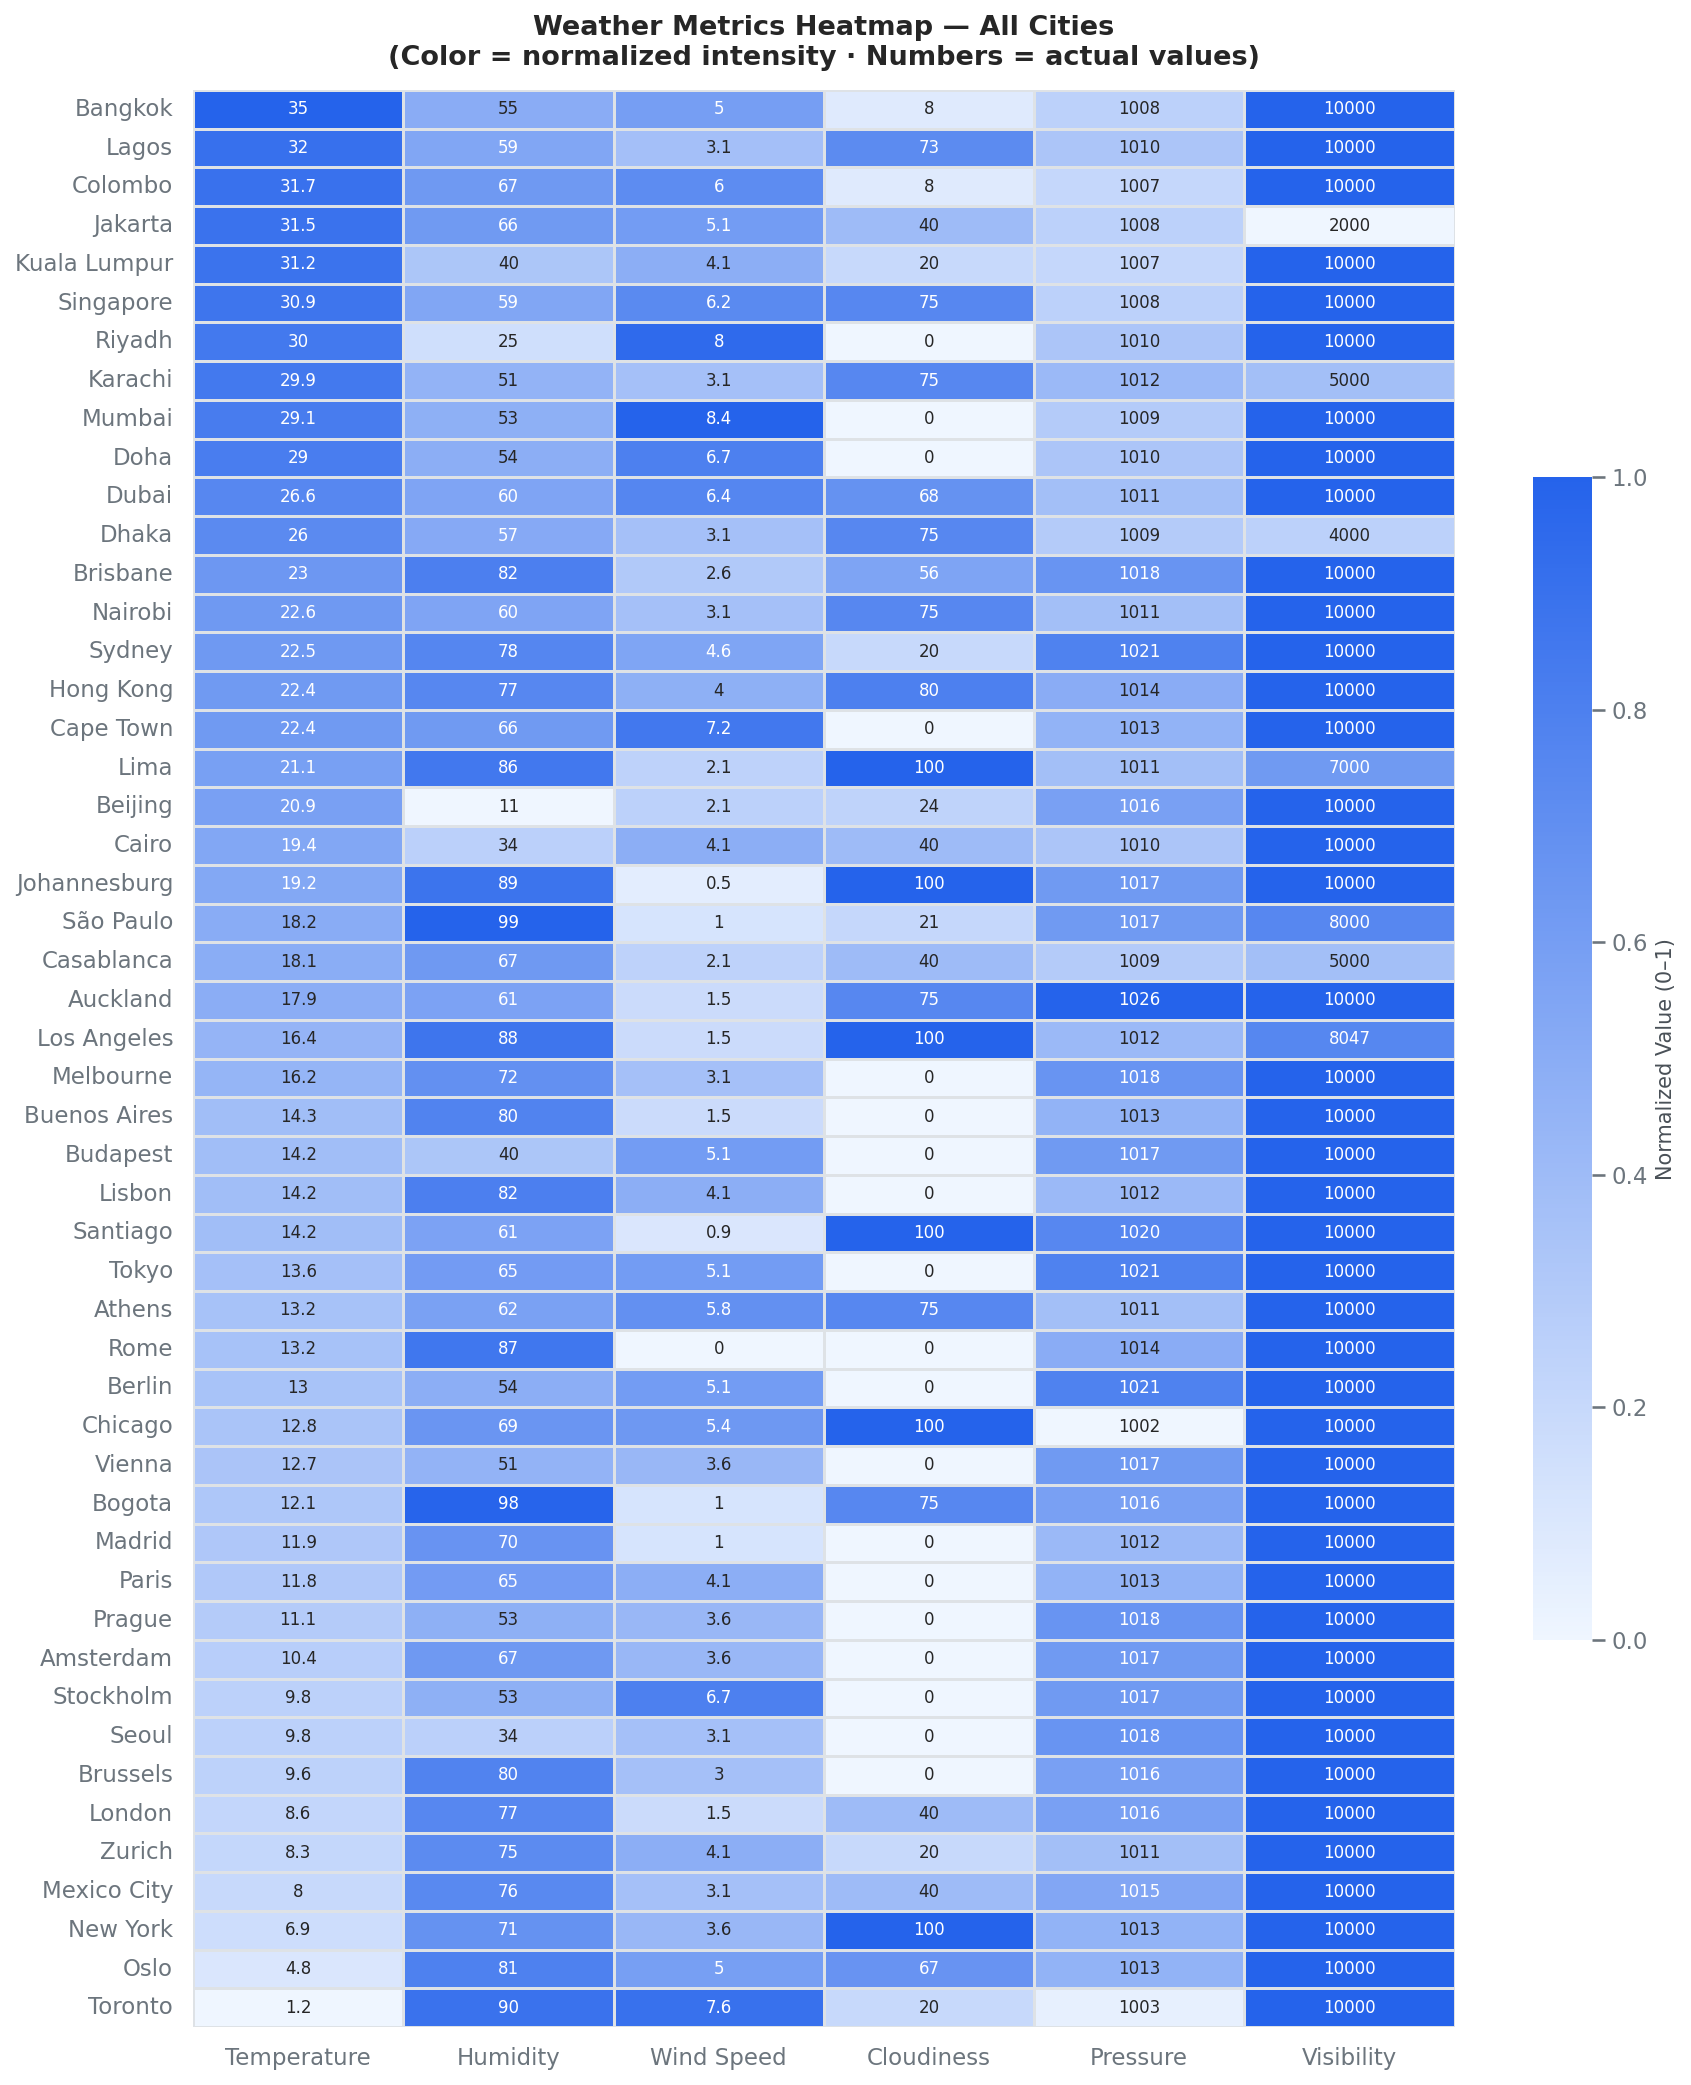

In [21]:
# ── VIZ 2: Heatmap — City vs Normalized Weather Metrics ──

metrics = ["temperature_c", "humidity_pct", "wind_speed_mps",
           "cloudiness_pct", "pressure_hpa", "visibility_m"]

labels  = ["Temperature", "Humidity", "Wind Speed",
           "Cloudiness", "Pressure", "Visibility"]

# Normalize each metric 0–1 for fair comparison
heatmap_df = latest.set_index("city")[metrics].copy()
normalized = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())
normalized.columns = labels

fig, ax = plt.subplots(figsize=(12, 14))

cmap = LinearSegmentedColormap.from_list(
    "professional", ["#eff6ff", "#2563eb"], N=256
)

sns.heatmap(
    normalized,
    ax=ax,
    cmap=cmap,
    annot=heatmap_df.round(1).values,
    fmt="g",
    linewidths=0.5,
    linecolor="#dee2e6",
    cbar_kws={"label": "Normalized Value (0–1)", "shrink": 0.6},
    annot_kws={"size": 8}
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Weather Metrics Heatmap — All Cities\n(Color = normalized intensity · Numbers = actual values)")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../notebooks/viz2_heatmap_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## Wind Rose Style: Wind Speed by Region

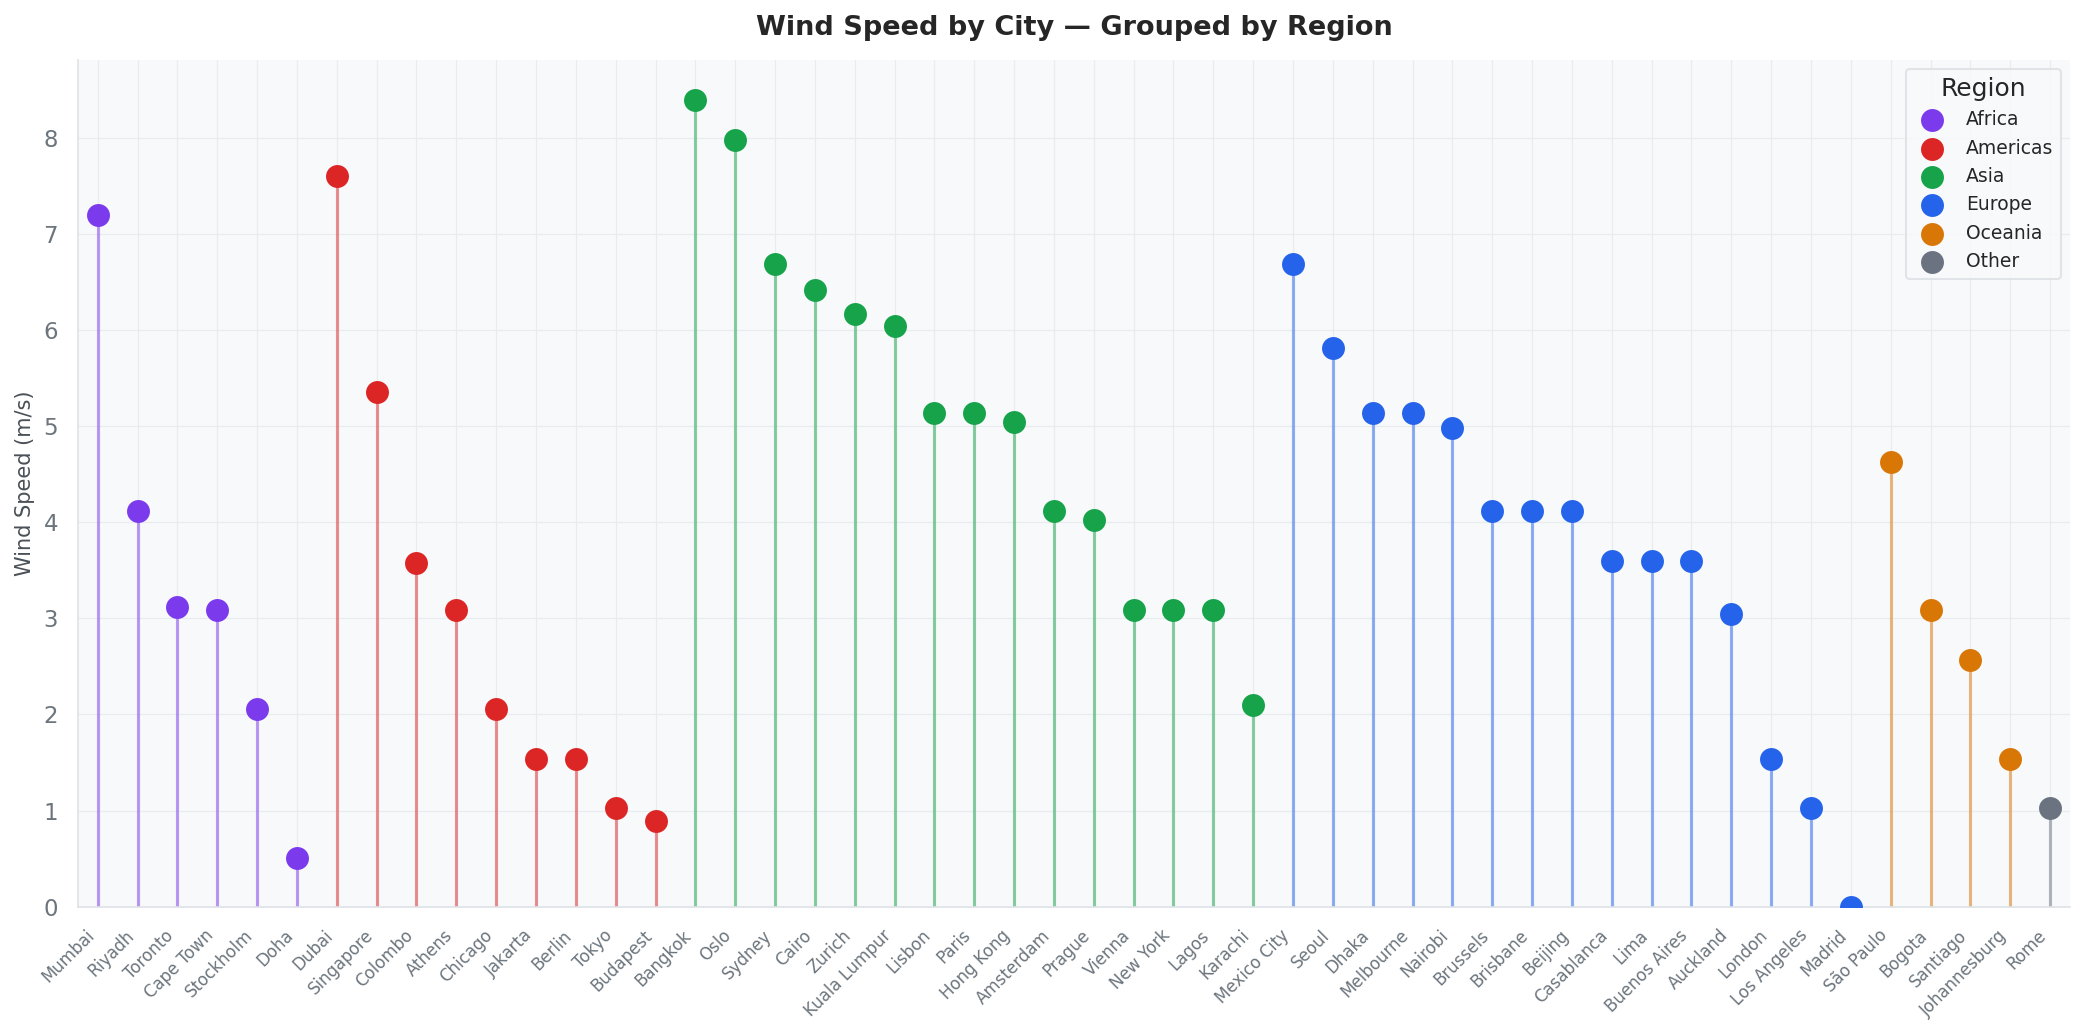

In [22]:
# ── VIZ 3: Wind Speed — Grouped by Region ─────────────────

region_map = {
    "London":"Europe","Paris":"Europe","Berlin":"Europe",
    "Rome":"Europe","Madrid":"Europe","Amsterdam":"Europe",
    "Vienna":"Europe","Stockholm":"Europe","Oslo":"Europe",
    "Zurich":"Europe","Brussels":"Europe","Lisbon":"Europe",
    "Athens":"Europe","Prague":"Europe","Budapest":"Europe",
    "Tokyo":"Asia","Singapore":"Asia","Dubai":"Asia",
    "Colombo":"Asia","Mumbai":"Asia","Bangkok":"Asia",
    "Seoul":"Asia","Beijing":"Asia","Kuala Lumpur":"Asia",
    "Jakarta":"Asia","Hong Kong":"Asia","Karachi":"Asia",
    "Dhaka":"Asia","Riyadh":"Asia","Doha":"Asia",
    "New York":"Americas","Toronto":"Americas","Los Angeles":"Americas",
    "Chicago":"Americas","Sao Paulo":"Americas","Mexico City":"Americas",
    "Buenos Aires":"Americas","Lima":"Americas","Bogota":"Americas",
    "Santiago":"Americas",
    "Sydney":"Oceania","Melbourne":"Oceania",
    "Auckland":"Oceania","Brisbane":"Oceania",
    "Cape Town":"Africa","Cairo":"Africa","Lagos":"Africa",
    "Nairobi":"Africa","Casablanca":"Africa","Johannesburg":"Africa",
}

latest["region"] = latest["city"].map(region_map).fillna("Other")

region_colors = {
    "Europe"  : "#2563eb",
    "Asia"    : "#16a34a",
    "Americas": "#dc2626",
    "Oceania" : "#d97706",
    "Africa"  : "#7c3aed",
}

fig, ax = plt.subplots(figsize=(14, 7))

for region, grp in latest.groupby("region"):
    grp_sorted = grp.sort_values("wind_speed_mps", ascending=False)
    ax.scatter(
        grp_sorted["city"], grp_sorted["wind_speed_mps"],
        color=region_colors.get(region, NEUTRAL),
        s=100, zorder=4, label=region
    )
    for _, row in grp_sorted.iterrows():
        ax.plot(
            [row["city"], row["city"]],
            [0, row["wind_speed_mps"]],
            color=region_colors.get(region, NEUTRAL),
            linewidth=1.5, alpha=0.5
        )

ax.set_xticklabels(latest.sort_values("wind_speed_mps", ascending=False)["city"],
                   rotation=45, ha="right", fontsize=8)

# Sort x axis by wind speed
order = latest.sort_values("wind_speed_mps", ascending=False)["city"].tolist()
ax.set_xlim(-0.5, len(order) - 0.5)

ax.set_ylabel("Wind Speed (m/s)")
ax.set_title("Wind Speed by City — Grouped by Region")
ax.legend(title="Region", loc="upper right")
ax.set_ylim(0)

plt.tight_layout()
plt.savefig("../notebooks/viz3_wind_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

## Humidity vs Temperature Quadrant Analysis

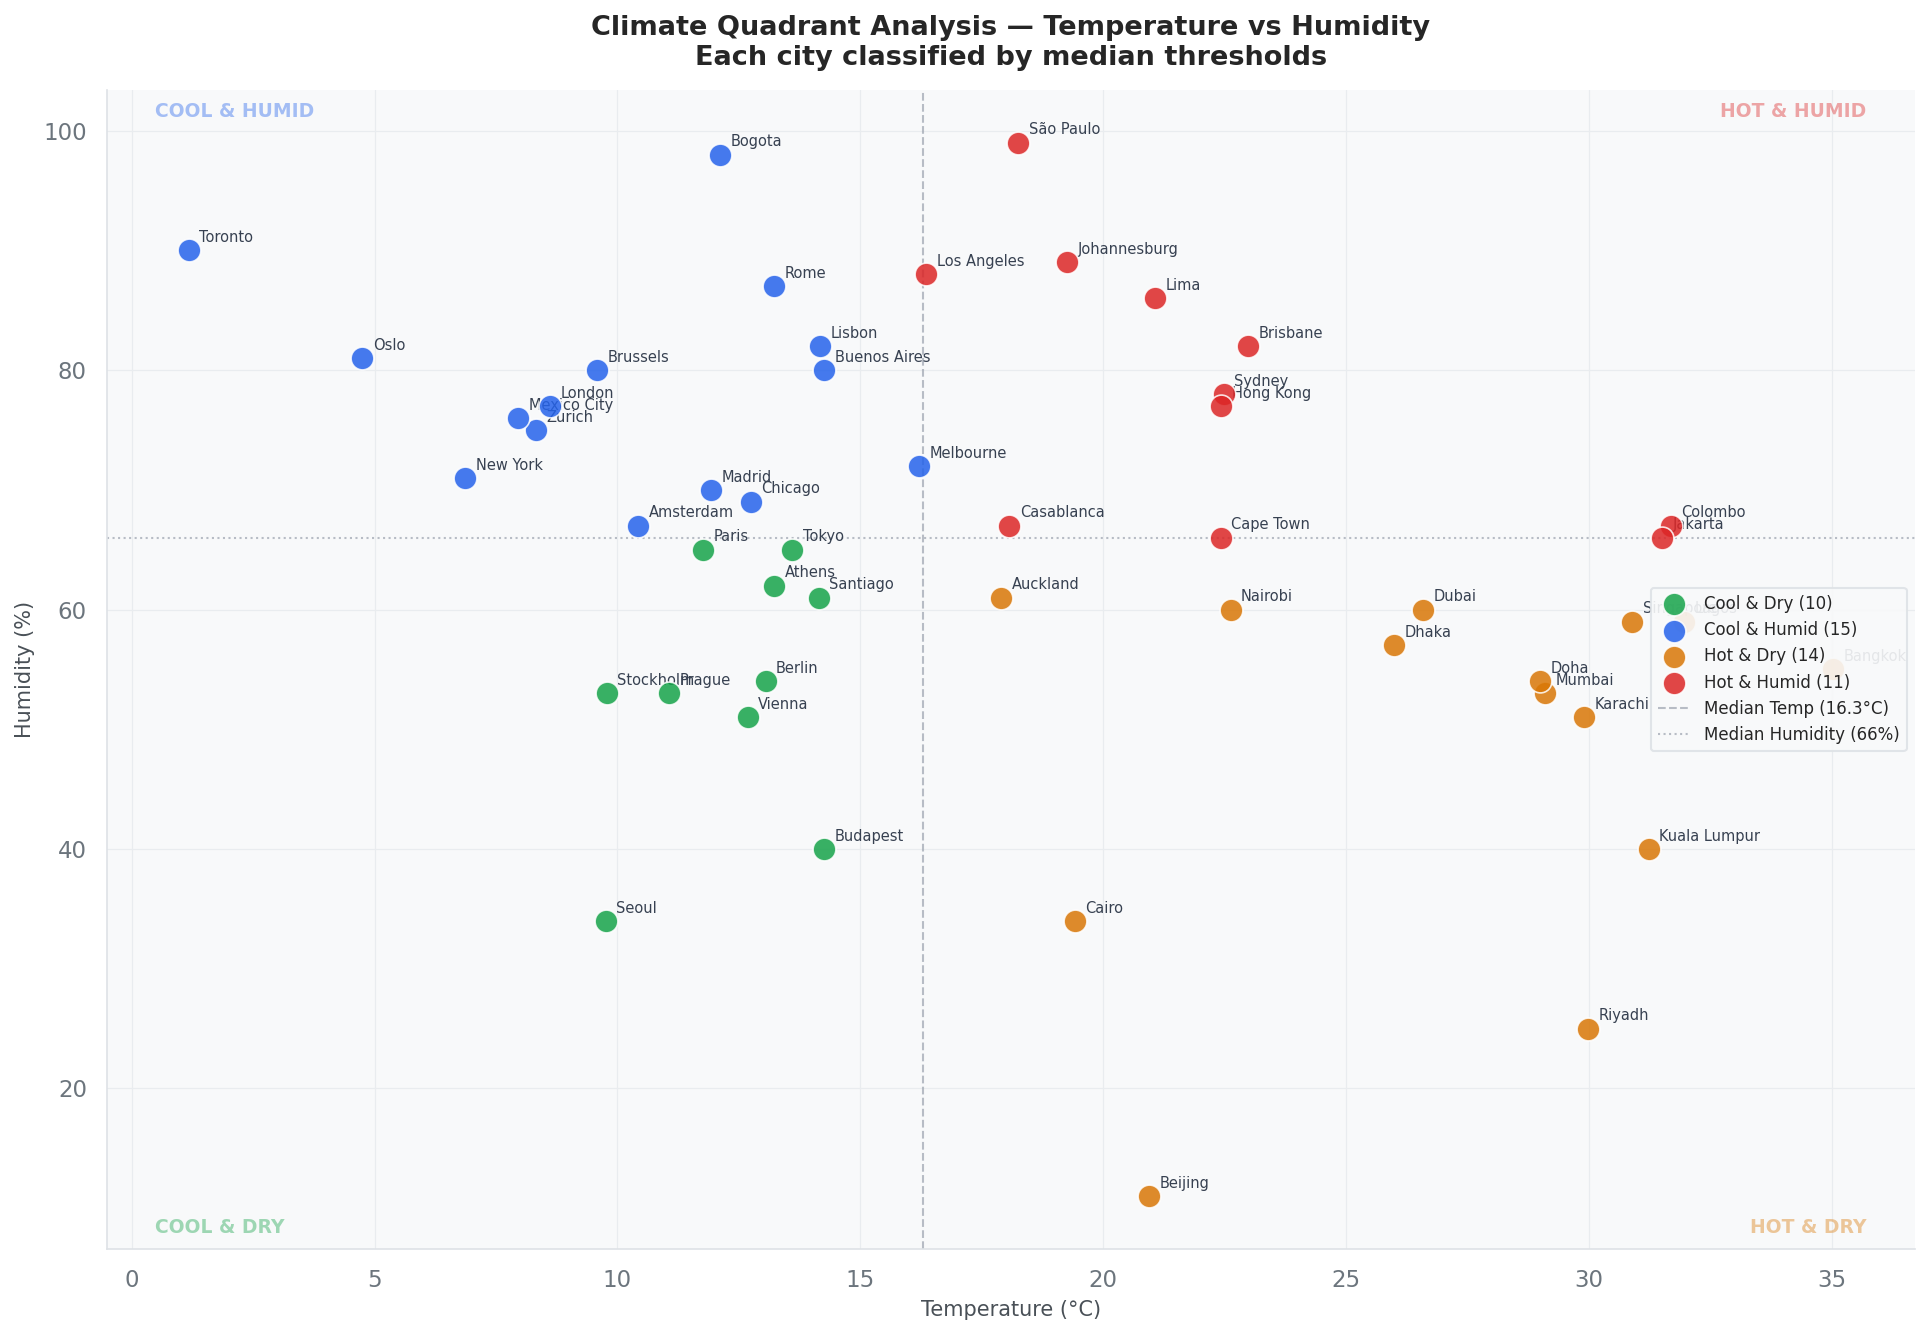

In [23]:
# ── VIZ 4: Quadrant Analysis — Humidity vs Temperature ────

fig, ax = plt.subplots(figsize=(13, 9))

temp_mid = latest["temperature_c"].median()
humi_mid = latest["humidity_pct"].median()

quadrant_colors = {
    "Hot & Humid"  : "#dc2626",
    "Hot & Dry"    : "#d97706",
    "Cool & Humid" : "#2563eb",
    "Cool & Dry"   : "#16a34a",
}

def get_quadrant(row):
    if row["temperature_c"] >= temp_mid and row["humidity_pct"] >= humi_mid:
        return "Hot & Humid"
    elif row["temperature_c"] >= temp_mid and row["humidity_pct"] < humi_mid:
        return "Hot & Dry"
    elif row["temperature_c"] < temp_mid and row["humidity_pct"] >= humi_mid:
        return "Cool & Humid"
    else:
        return "Cool & Dry"

latest["quadrant"] = latest.apply(get_quadrant, axis=1)

for quadrant, grp in latest.groupby("quadrant"):
    ax.scatter(
        grp["temperature_c"], grp["humidity_pct"],
        color=quadrant_colors[quadrant],
        s=120, label=f"{quadrant} ({len(grp)})",
        zorder=4, alpha=0.85, edgecolors="white", linewidths=0.8
    )

for _, row in latest.iterrows():
    ax.annotate(
        row["city"],
        xy=(row["temperature_c"], row["humidity_pct"]),
        xytext=(5, 4), textcoords="offset points",
        fontsize=7, color="#374151"
    )

# Quadrant dividers
ax.axvline(temp_mid, color="#9ca3af", linewidth=1,
           linestyle="--", alpha=0.7, label=f"Median Temp ({temp_mid:.1f}°C)")
ax.axhline(humi_mid, color="#9ca3af", linewidth=1,
           linestyle=":",  alpha=0.7, label=f"Median Humidity ({humi_mid:.0f}%)")

# Quadrant labels
pad = 1
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[1]-pad, ylim[1]-pad, "HOT & HUMID",
        ha="right", va="top",    fontsize=9, color="#dc2626", alpha=0.4, fontweight="bold")
ax.text(xlim[1]-pad, ylim[0]+pad, "HOT & DRY",
        ha="right", va="bottom", fontsize=9, color="#d97706", alpha=0.4, fontweight="bold")
ax.text(xlim[0]+pad, ylim[1]-pad, "COOL & HUMID",
        ha="left",  va="top",    fontsize=9, color="#2563eb", alpha=0.4, fontweight="bold")
ax.text(xlim[0]+pad, ylim[0]+pad, "COOL & DRY",
        ha="left",  va="bottom", fontsize=9, color="#16a34a", alpha=0.4, fontweight="bold")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Humidity (%)")
ax.set_title("Climate Quadrant Analysis — Temperature vs Humidity\nEach city classified by median thresholds")
ax.legend(fontsize=8, loc="center right")

plt.tight_layout()
plt.savefig("../notebooks/viz4_quadrant_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Regional Box Plot Distribution

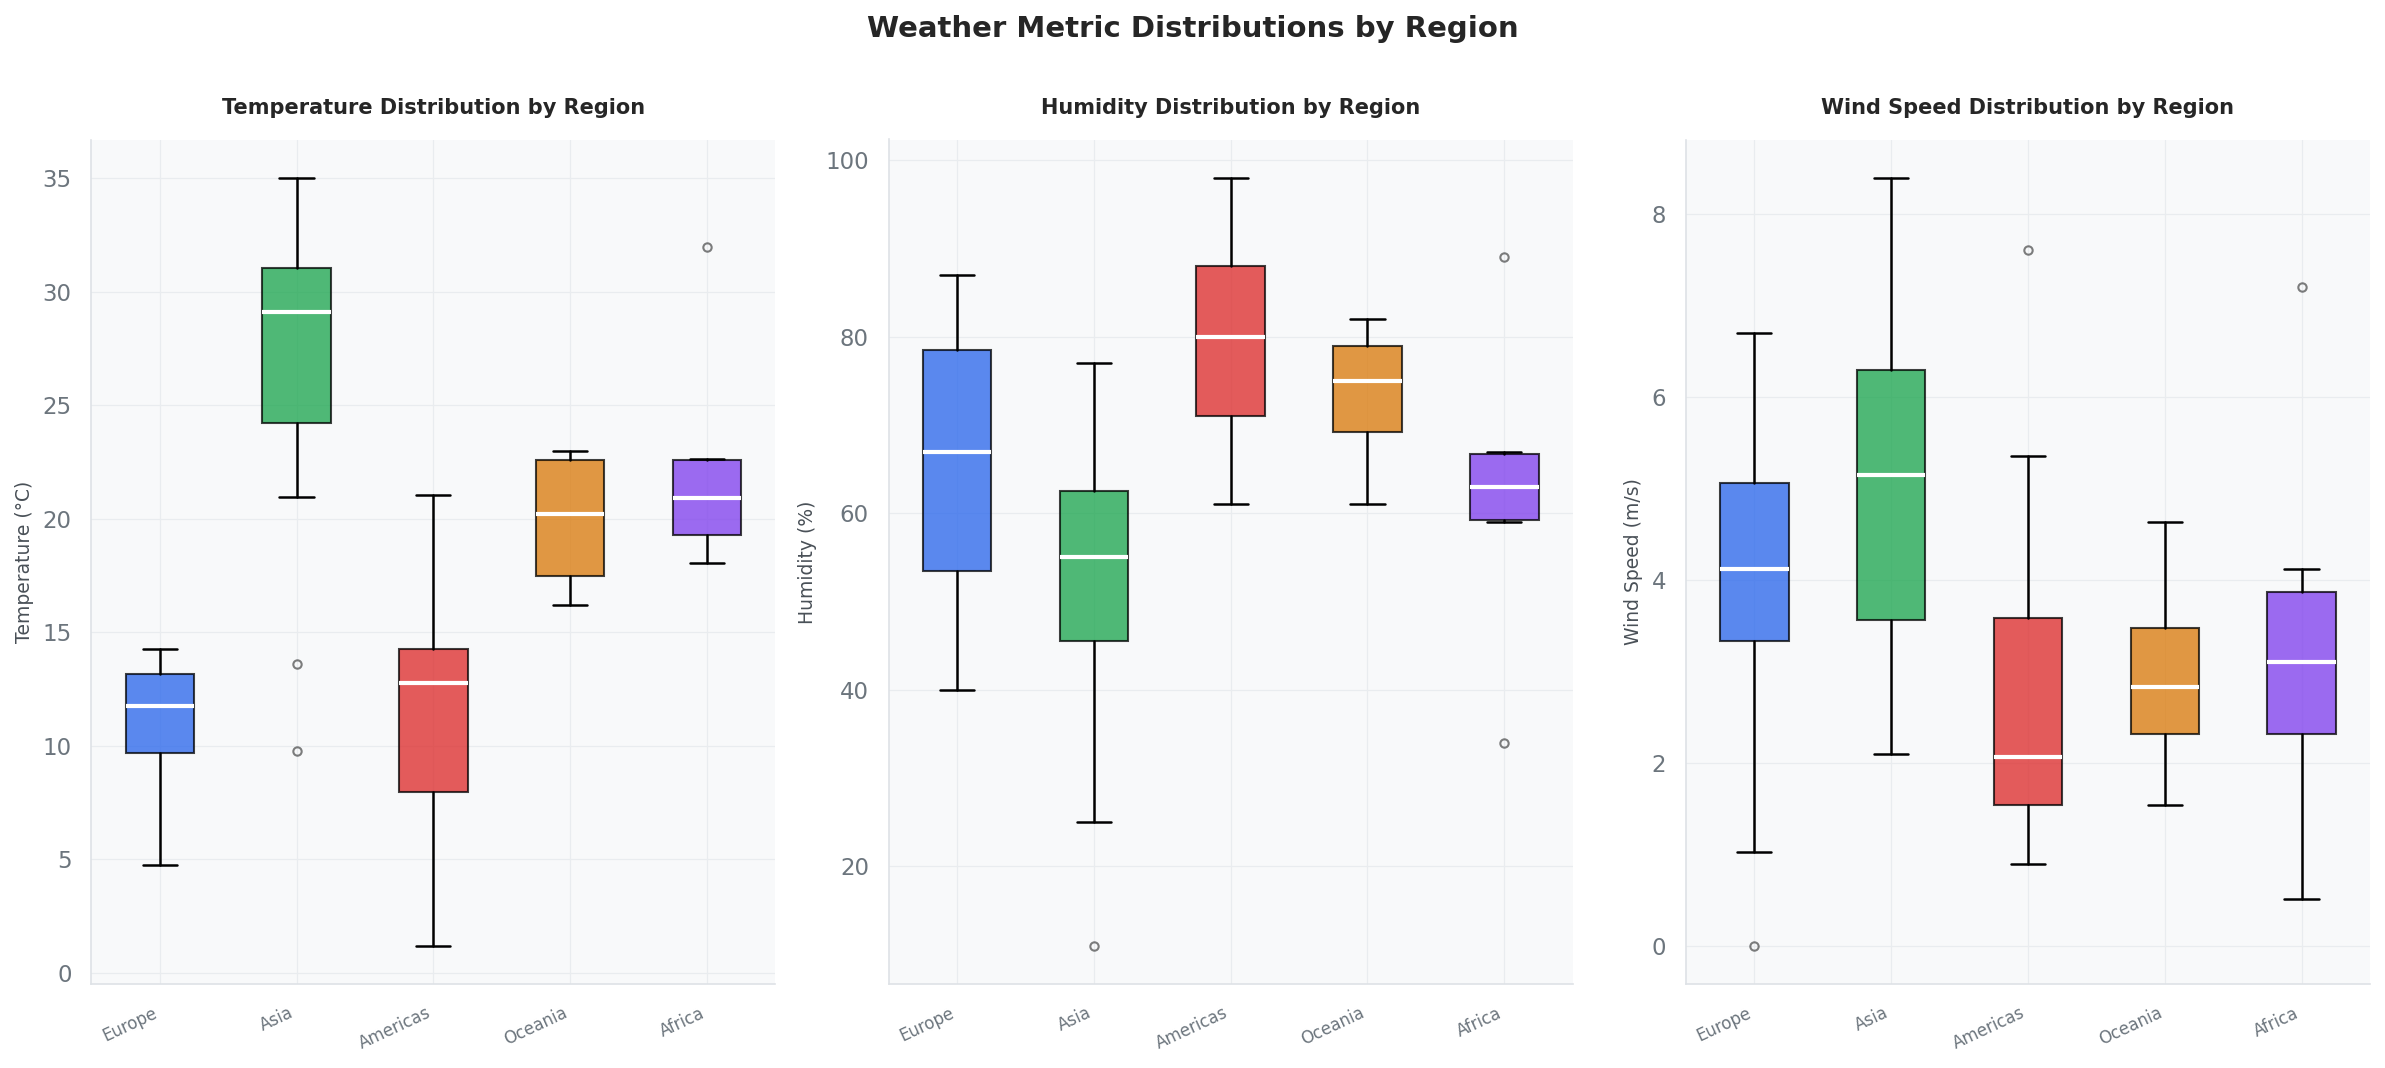

In [24]:
# ── VIZ 5: Box Plot — Temperature Distribution by Region ──

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

metrics_box = [
    ("temperature_c", "Temperature (°C)",  "Temperature Distribution by Region"),
    ("humidity_pct",  "Humidity (%)",       "Humidity Distribution by Region"),
    ("wind_speed_mps","Wind Speed (m/s)",   "Wind Speed Distribution by Region"),
]

region_order  = ["Europe", "Asia", "Americas", "Oceania", "Africa"]
region_palette = {
    "Europe"  : "#2563eb",
    "Asia"    : "#16a34a",
    "Americas": "#dc2626",
    "Oceania" : "#d97706",
    "Africa"  : "#7c3aed",
}

for ax, (metric, ylabel, title) in zip(axes, metrics_box):
    data_by_region = [
        latest[latest["region"] == r][metric].dropna().values
        for r in region_order
        if len(latest[latest["region"] == r]) > 0
    ]
    valid_regions = [
        r for r in region_order
        if len(latest[latest["region"] == r]) > 0
    ]

    bp = ax.boxplot(
        data_by_region,
        patch_artist=True,
        notch=False,
        widths=0.5,
        medianprops={"color": "white", "linewidth": 2},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}
    )

    for patch, region in zip(bp["boxes"], valid_regions):
        patch.set_facecolor(region_palette[region])
        patch.set_alpha(0.75)

    ax.set_xticklabels(valid_regions, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)

plt.suptitle("Weather Metric Distributions by Region",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../notebooks/viz5_regional_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Pressure vs Visibility Bubble Chart

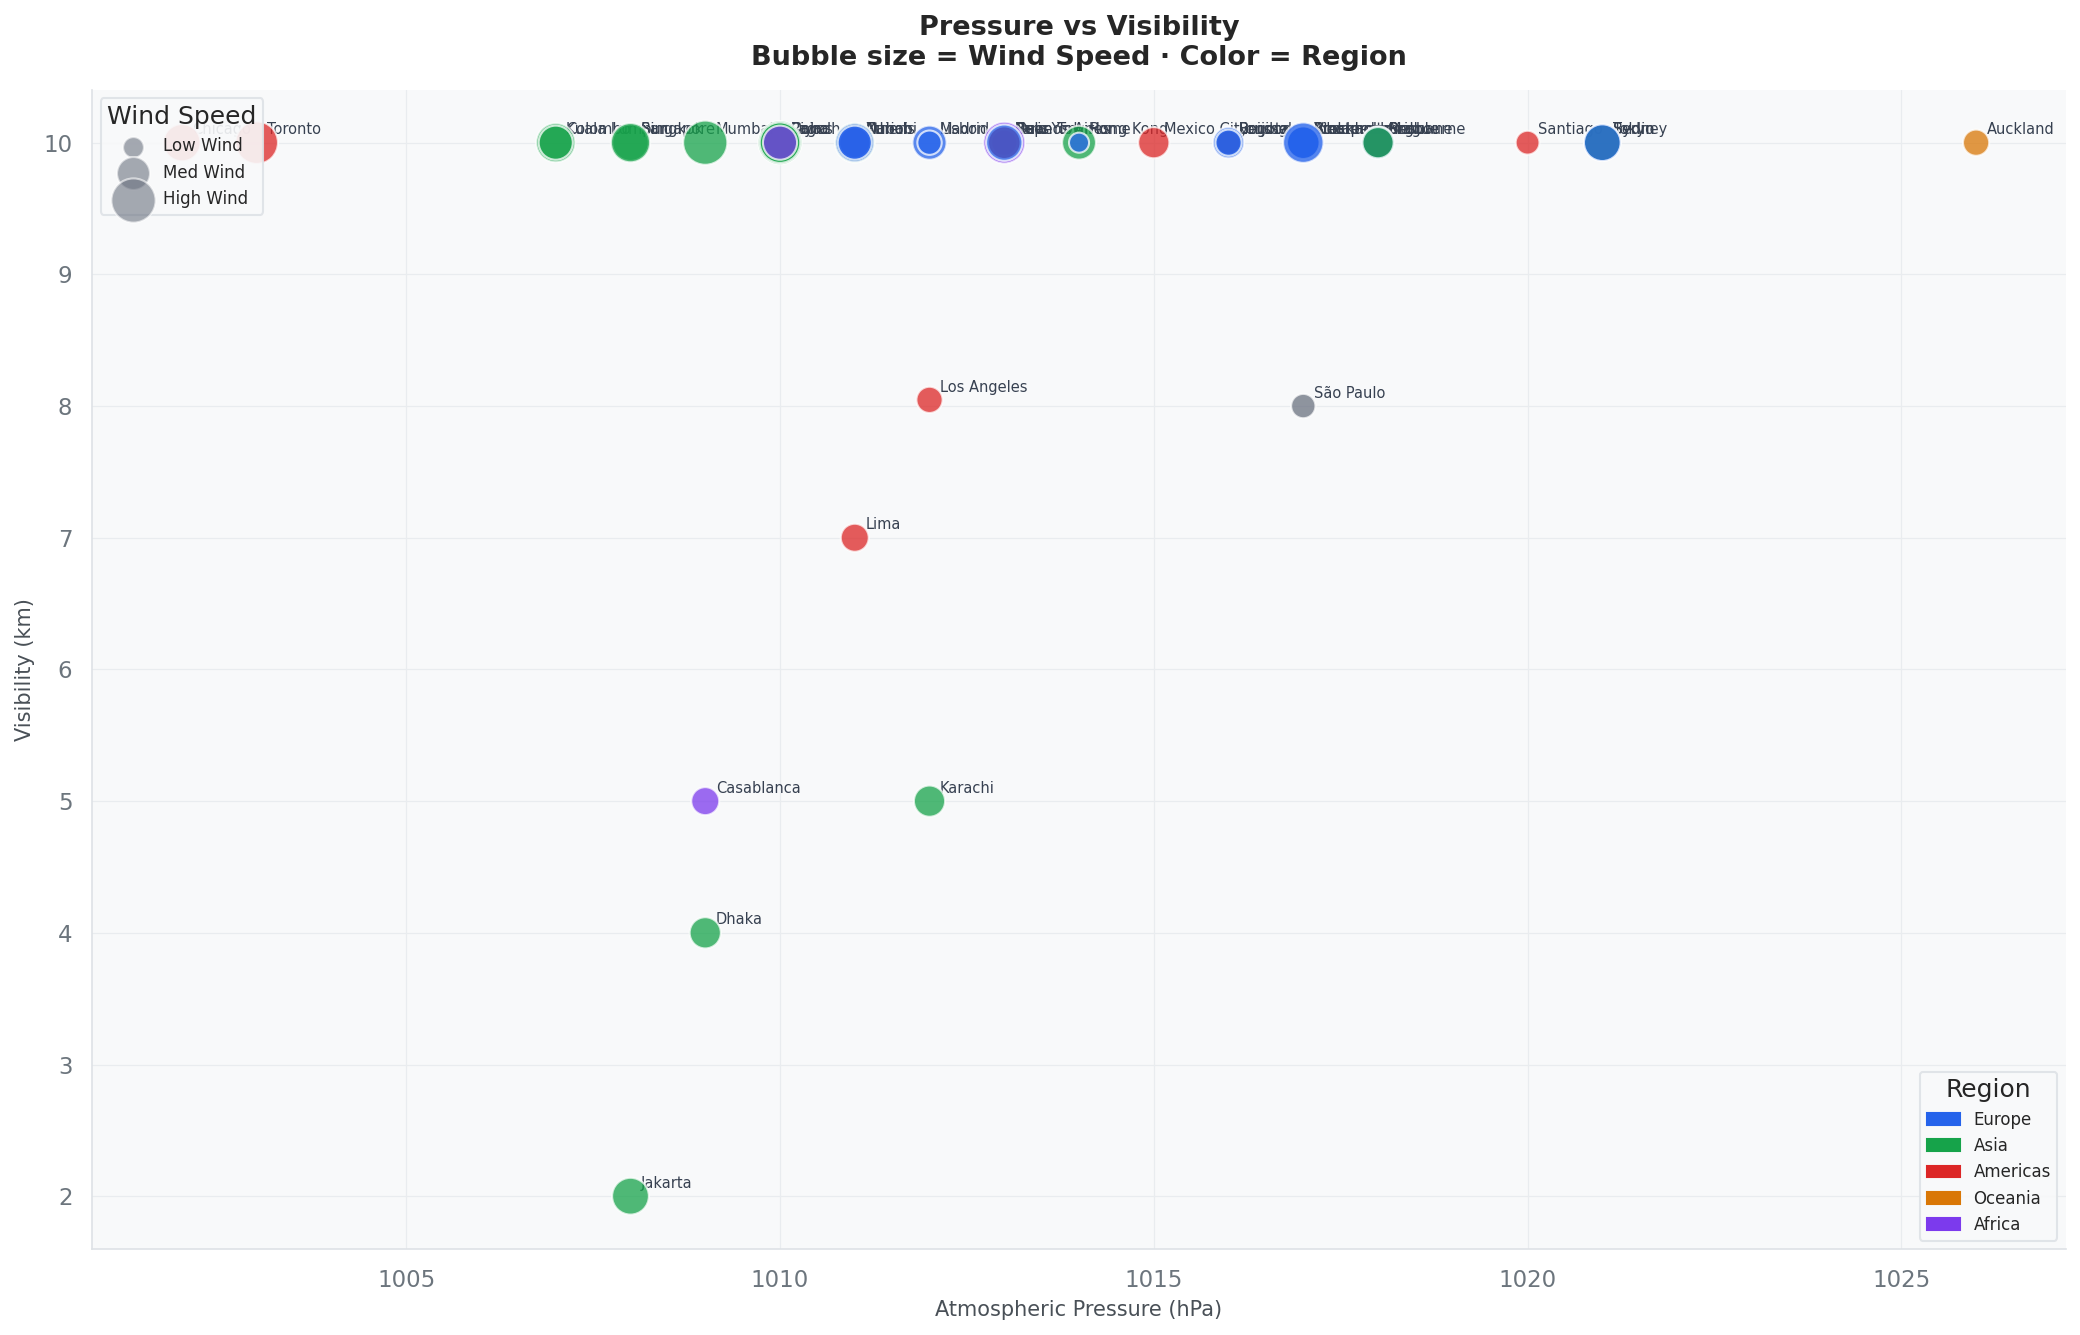

In [25]:
# ── VIZ 6: Bubble Chart — Pressure vs Visibility ──────────

fig, ax = plt.subplots(figsize=(14, 9))

bubble_sizes = (
    (latest["wind_speed_mps"] - latest["wind_speed_mps"].min() + 1) /
    (latest["wind_speed_mps"].max() - latest["wind_speed_mps"].min() + 1)
) * 400 + 50

colors_bubble = [
    region_colors.get(r, NEUTRAL) for r in latest["region"]
]

scatter = ax.scatter(
    latest["pressure_hpa"],
    latest["visibility_m"] / 1000,
    s=bubble_sizes,
    c=colors_bubble,
    alpha=0.75,
    edgecolors="white",
    linewidths=1,
    zorder=4
)

for _, row in latest.iterrows():
    ax.annotate(
        row["city"],
        xy=(row["pressure_hpa"], row["visibility_m"] / 1000),
        xytext=(5, 4), textcoords="offset points",
        fontsize=7, color="#374151"
    )

# Legend for regions
handles = [
    mpatches.Patch(color=col, label=reg)
    for reg, col in region_colors.items()
]
legend1 = ax.legend(handles=handles, title="Region",
                    loc="lower right", fontsize=8)
ax.add_artist(legend1)

# Legend for bubble size
for size, label in [(100, "Low Wind"), (250, "Med Wind"), (450, "High Wind")]:
    ax.scatter([], [], s=size, color=NEUTRAL, alpha=0.6,
               label=label, edgecolors="white")
ax.legend(title="Wind Speed", loc="upper left", fontsize=8)

ax.set_xlabel("Atmospheric Pressure (hPa)")
ax.set_ylabel("Visibility (km)")
ax.set_title("Pressure vs Visibility\nBubble size = Wind Speed · Color = Region")

plt.tight_layout()
plt.savefig("../notebooks/viz6_pressure_visibility_bubble.png", dpi=150, bbox_inches="tight")
plt.show()

## Weather Condition Treemap

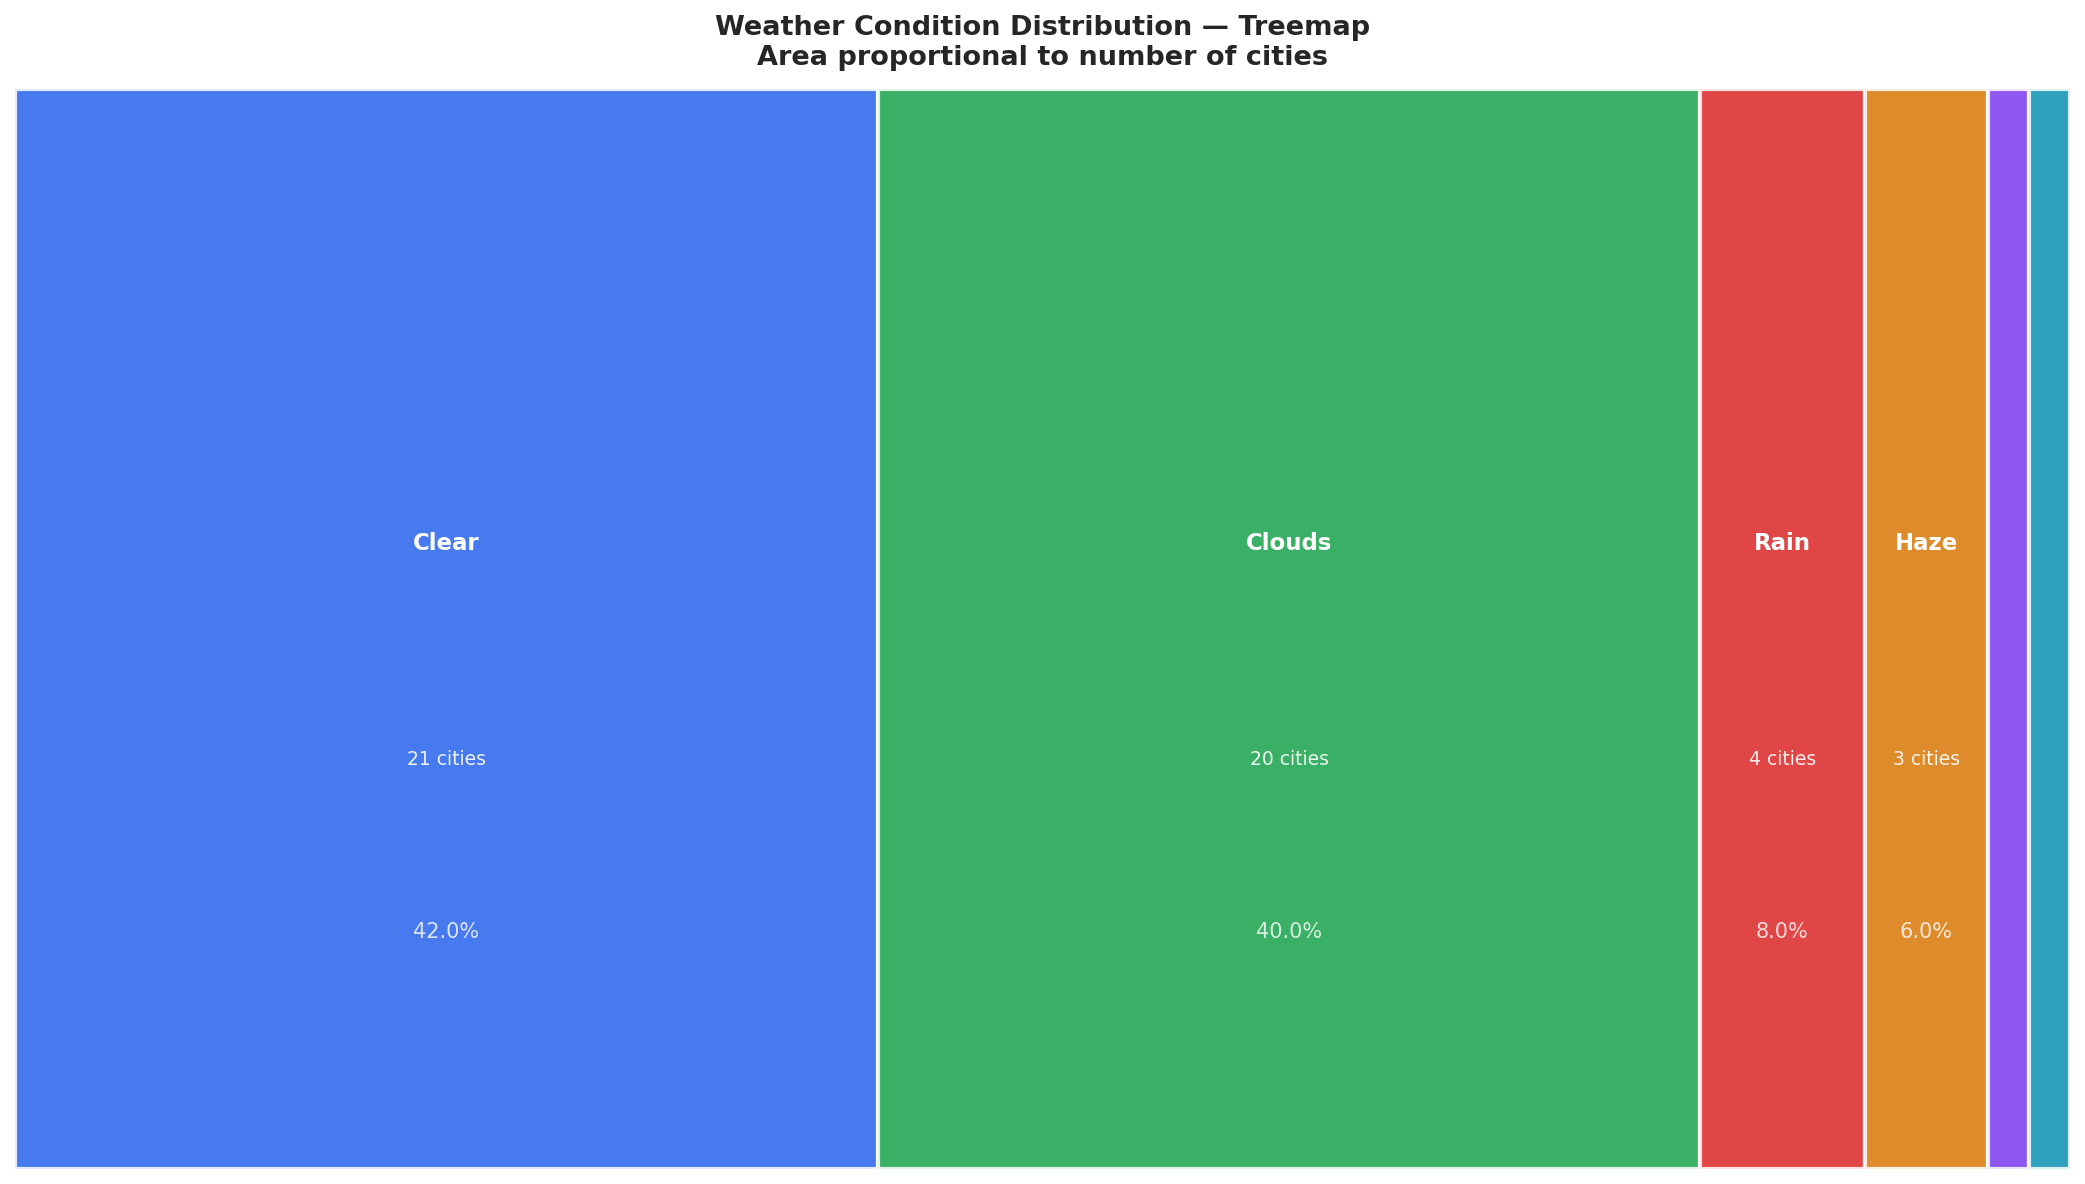

In [27]:
# ── VIZ 7: Weather Condition Treemap ──────────────────────

fig, ax = plt.subplots(figsize=(14, 8))

condition_counts = latest["weather_condition"].value_counts()
total            = condition_counts.sum()
colors_tree      = [PALETTE[i % len(PALETTE)] for i in range(len(condition_counts))]

# Manual treemap using nested rectangles
values     = condition_counts.values
conditions = condition_counts.index.tolist()
proportions = values / total

x, y    = 0.0, 0.0
width   = 1.0
height  = 1.0
rects   = []

remaining = list(zip(proportions, conditions, colors_tree))
remaining.sort(reverse=True)

cur_x = 0.0
for prop, cond, color in remaining:
    w = prop
    rect = plt.Rectangle((cur_x, 0), w, 1.0,
                          facecolor=color, edgecolor="white",
                          linewidth=2, alpha=0.85)
    ax.add_patch(rect)

    count = condition_counts[cond]
    pct   = prop * 100

    if w > 0.05:
        ax.text(cur_x + w/2, 0.58, cond,
                ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")
        ax.text(cur_x + w/2, 0.38, f"{count} cities",
                ha="center", va="center",
                fontsize=9, color="white", alpha=0.9)
        ax.text(cur_x + w/2, 0.22, f"{pct:.1f}%",
                ha="center", va="center",
                fontsize=10, color="white", alpha=0.8)
    cur_x += w

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Weather Condition Distribution — Treemap\nArea proportional to number of cities",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/viz7_condition_treemap.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation Matrix

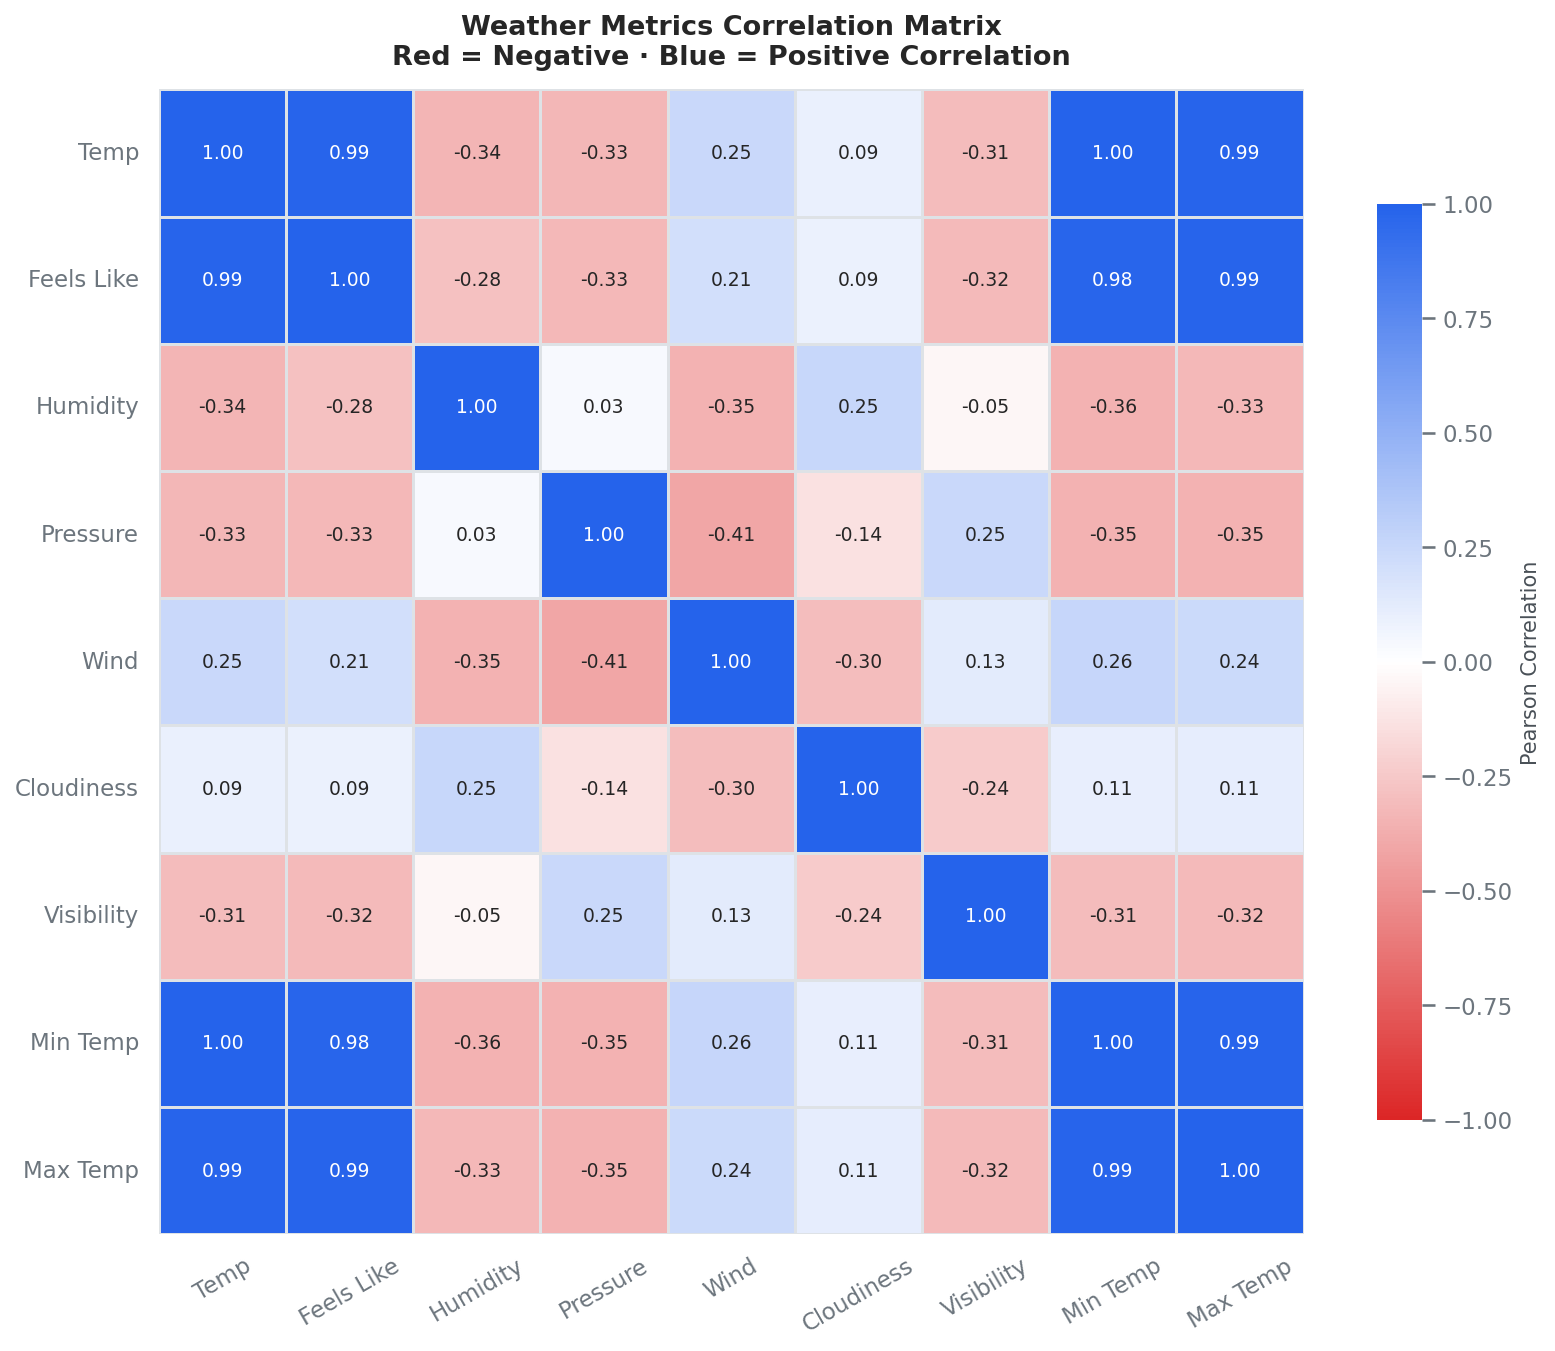

In [28]:
# ── VIZ 8: Correlation Matrix ─────────────────────────────

corr_cols = ["temperature_c", "feels_like_c", "humidity_pct",
             "pressure_hpa", "wind_speed_mps", "cloudiness_pct",
             "visibility_m", "temp_min_c", "temp_max_c"]

corr_labels = ["Temp", "Feels Like", "Humidity", "Pressure",
               "Wind", "Cloudiness", "Visibility", "Min Temp", "Max Temp"]

corr_matrix = latest[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))

cmap_corr = LinearSegmentedColormap.from_list(
    "corr", ["#dc2626", "#ffffff", "#2563eb"], N=256
)

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap=cmap_corr,
    annot=True,
    fmt=".2f",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#dee2e6",
    annot_kws={"size": 9},
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
)

ax.set_title("Weather Metrics Correlation Matrix\nRed = Negative · Blue = Positive Correlation")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../notebooks/viz8_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Regional Radar Chart

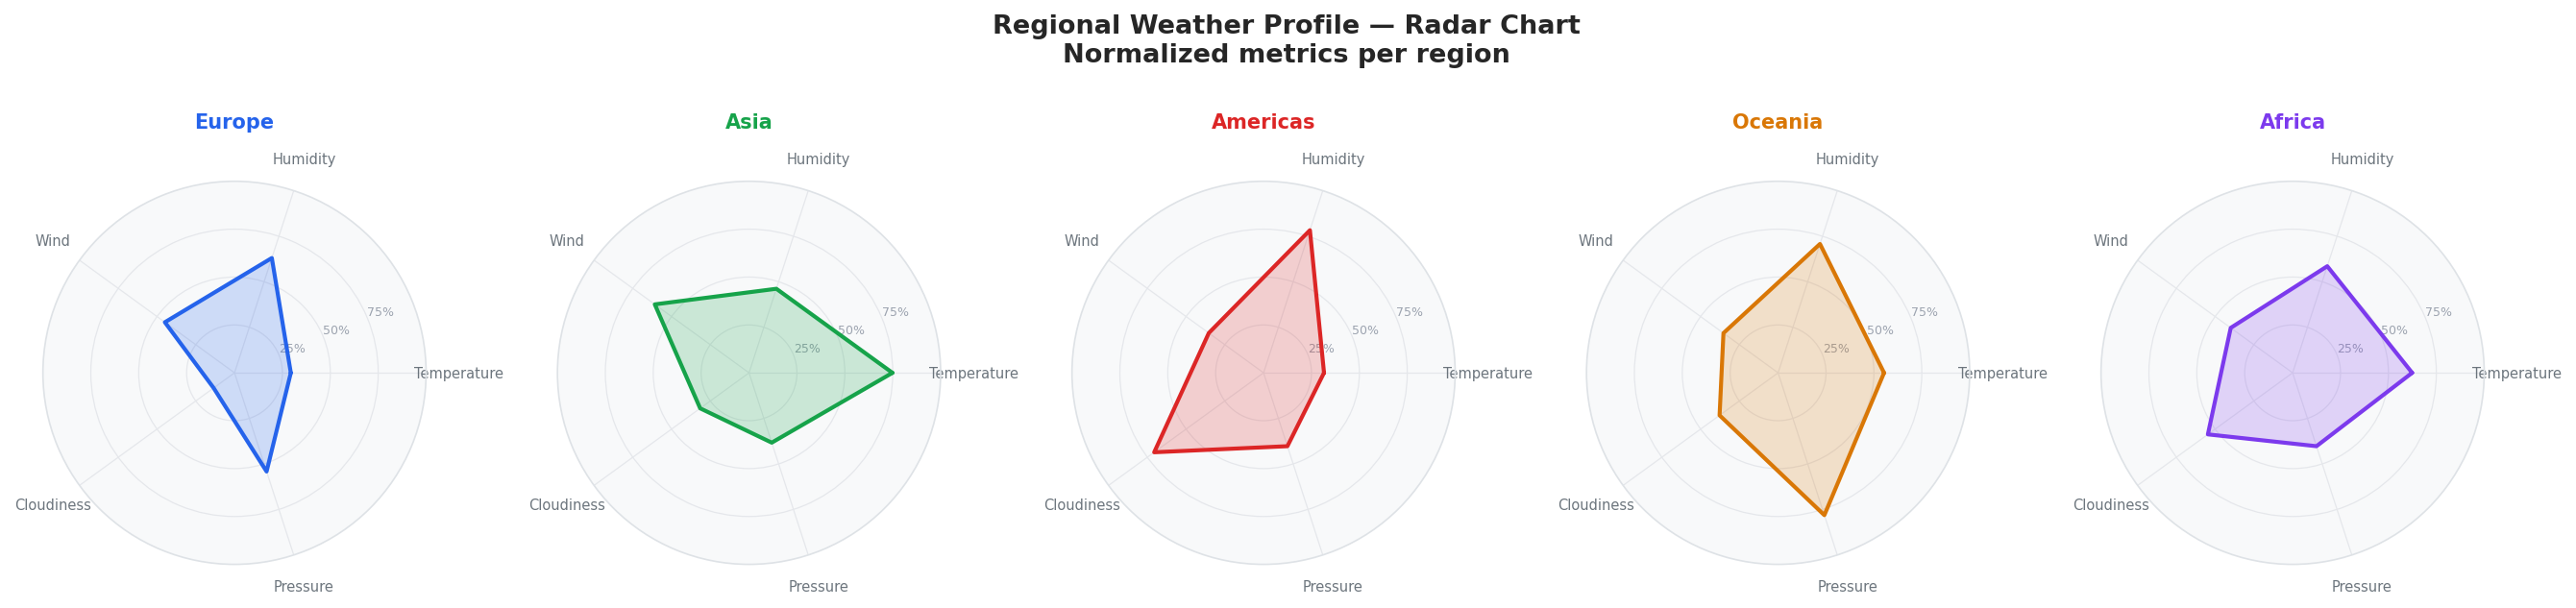

In [29]:
# ── VIZ 9: Radar Chart — Regional Weather Profile ─────────

from matplotlib.patches import FancyArrowPatch

regions       = ["Europe", "Asia", "Americas", "Oceania", "Africa"]
radar_metrics = ["temperature_c", "humidity_pct", "wind_speed_mps",
                 "cloudiness_pct", "pressure_hpa"]
radar_labels  = ["Temperature", "Humidity", "Wind", "Cloudiness", "Pressure"]

# Normalize metrics 0–1
norm_df = latest.copy()
for col in radar_metrics:
    col_min = latest[col].min()
    col_max = latest[col].max()
    norm_df[col] = (latest[col] - col_min) / (col_max - col_min + 1e-9)

N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, len(regions), figsize=(18, 4),
                         subplot_kw={"polar": True})

for ax, region in zip(axes, regions):
    grp = norm_df[norm_df["region"] == region]
    if grp.empty:
        ax.set_title(region); continue

    values_r = grp[radar_metrics].mean().tolist()
    values_r += values_r[:1]

    color = region_colors.get(region, NEUTRAL)

    ax.plot(angles, values_r, color=color, linewidth=2)
    ax.fill(angles, values_r, color=color, alpha=0.2)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["25%", "50%", "75%"], fontsize=6, color="#9ca3af")
    ax.set_title(region, fontsize=10, fontweight="bold",
                 color=color, pad=12)
    ax.grid(color="#e5e7eb", linewidth=0.6)
    ax.spines["polar"].set_edgecolor("#dee2e6")

plt.suptitle("Regional Weather Profile — Radar Chart\nNormalized metrics per region",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("../notebooks/viz9_radar_regional.png", dpi=150, bbox_inches="tight")
plt.show()

## Executive Dashboard Summary

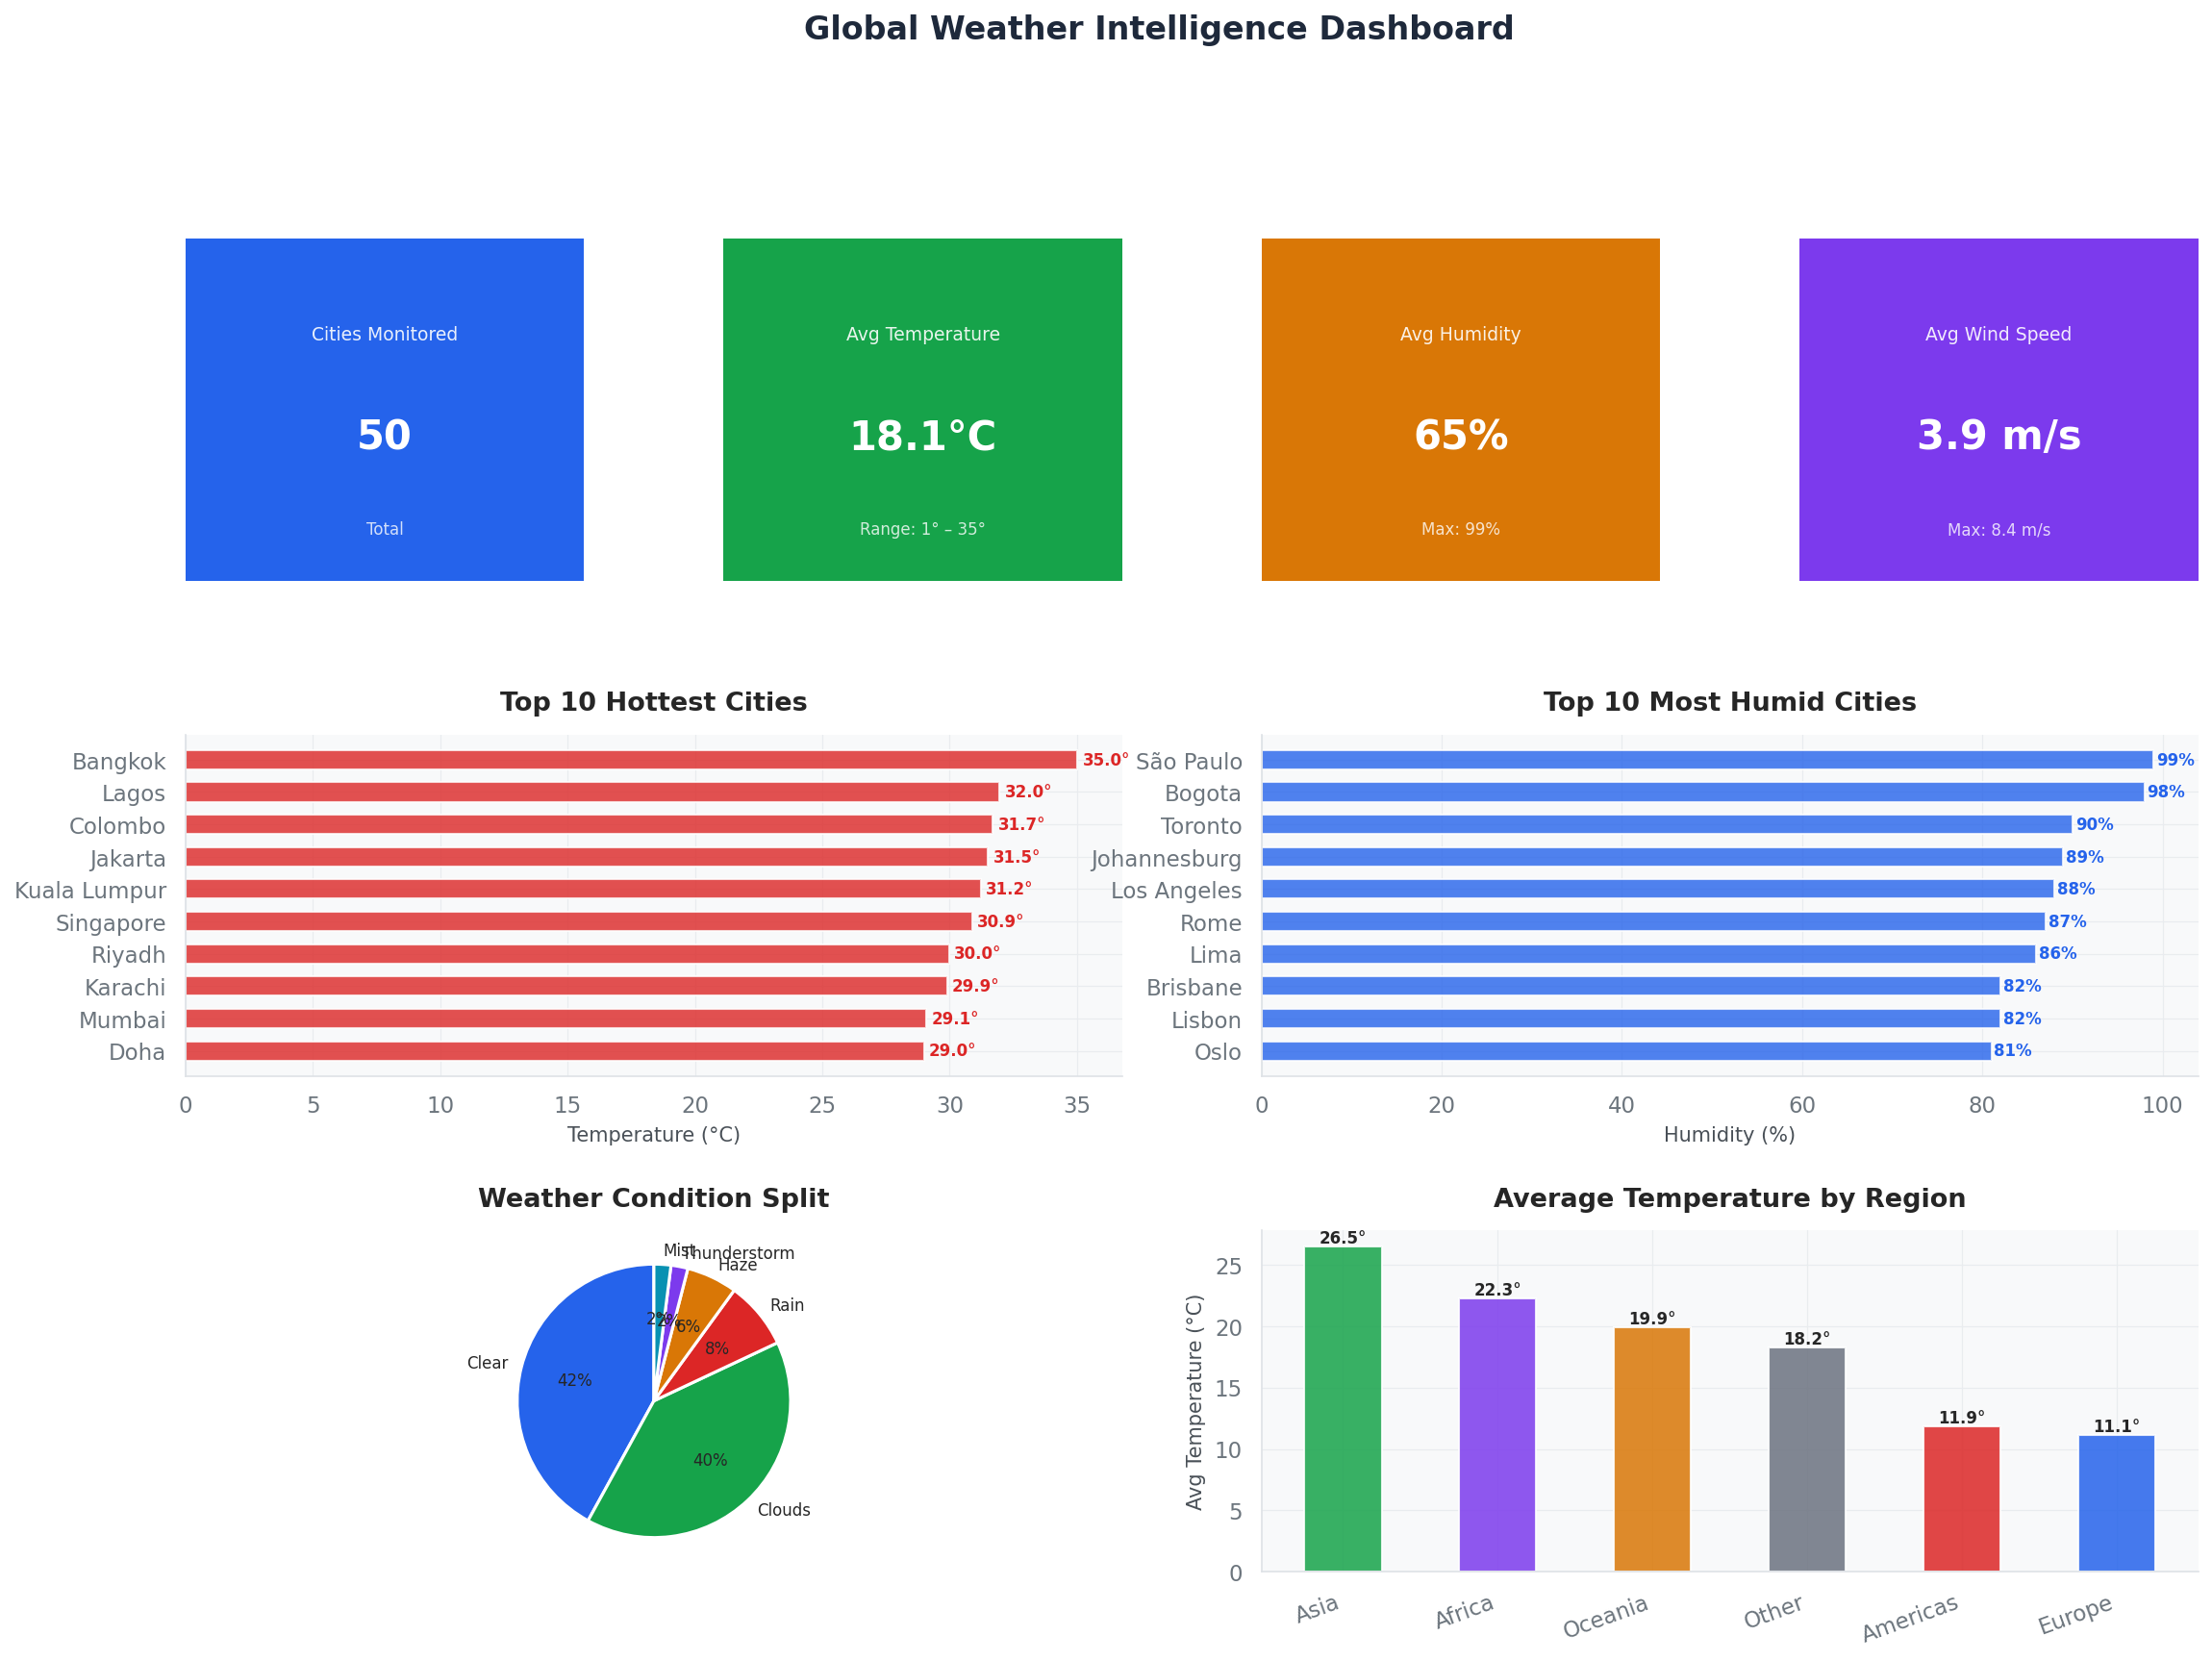

In [30]:
# ── VIZ 10: Executive Dashboard ───────────────────────────

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI Cards (top row) ───────────────────────────────────
kpis = [
    ("Cities Monitored",  f"{len(latest)}",
     ACCENT,   "Total"),
    ("Avg Temperature",   f"{latest['temperature_c'].mean():.1f}°C",
     POSITIVE, f"Range: {latest['temperature_c'].min():.0f}° – {latest['temperature_c'].max():.0f}°"),
    ("Avg Humidity",      f"{latest['humidity_pct'].mean():.0f}%",
     "#d97706", f"Max: {latest['humidity_pct'].max()}%"),
    ("Avg Wind Speed",    f"{latest['wind_speed_mps'].mean():.1f} m/s",
     "#7c3aed", f"Max: {latest['wind_speed_mps'].max():.1f} m/s"),
]

for i, (title, value, color, subtitle) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(color)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)
    ax_kpi.text(0.5, 0.72, title,   ha="center", va="center",
                transform=ax_kpi.transAxes,
                fontsize=9, color="white", alpha=0.9)
    ax_kpi.text(0.5, 0.42, value,   ha="center", va="center",
                transform=ax_kpi.transAxes,
                fontsize=20, color="white", fontweight="bold")
    ax_kpi.text(0.5, 0.15, subtitle, ha="center", va="center",
                transform=ax_kpi.transAxes,
                fontsize=8, color="white", alpha=0.8)

# ── Top 10 Hottest Cities ─────────────────────────────────
ax1 = fig.add_subplot(gs[1, :2])
top10 = latest.nlargest(10, "temperature_c")
bars  = ax1.barh(top10["city"], top10["temperature_c"],
                 color=NEGATIVE, alpha=0.8, edgecolor="white", height=0.6)
for bar, val in zip(bars, top10["temperature_c"]):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}°", va="center", fontsize=8, fontweight="bold",
             color=NEGATIVE)
ax1.set_title("Top 10 Hottest Cities")
ax1.set_xlabel("Temperature (°C)")
ax1.invert_yaxis()

# ── Top 10 Most Humid Cities ──────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:])
top10h = latest.nlargest(10, "humidity_pct")
bars2  = ax2.barh(top10h["city"], top10h["humidity_pct"],
                  color=ACCENT, alpha=0.8, edgecolor="white", height=0.6)
for bar, val in zip(bars2, top10h["humidity_pct"]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=8, fontweight="bold",
             color=ACCENT)
ax2.set_title("Top 10 Most Humid Cities")
ax2.set_xlabel("Humidity (%)")
ax2.invert_yaxis()

# ── Condition Pie ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :2])
cond_counts = latest["weather_condition"].value_counts()
ax3.pie(cond_counts.values,
        labels=cond_counts.index,
        autopct="%1.0f%%",
        colors=PALETTE[:len(cond_counts)],
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        textprops={"fontsize": 8})
ax3.set_title("Weather Condition Split")

# ── Region Avg Temperature Bar ────────────────────────────
ax4 = fig.add_subplot(gs[2, 2:])
reg_avg = latest.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
bar_colors = [region_colors.get(r, NEUTRAL) for r in reg_avg.index]
bars4 = ax4.bar(reg_avg.index, reg_avg.values,
                color=bar_colors, edgecolor="white",
                alpha=0.85, width=0.5)
for bar, val in zip(bars4, reg_avg.values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{val:.1f}°", ha="center", fontsize=8,
             fontweight="bold")
ax4.set_ylabel("Avg Temperature (°C)")
ax4.set_title("Average Temperature by Region")
ax4.set_xticklabels(reg_avg.index, rotation=20, ha="right")

fig.suptitle("Global Weather Intelligence Dashboard",
             fontsize=16, fontweight="bold", y=1.01, color="#1e293b")

plt.savefig("../notebooks/viz10_executive_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()